In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
# === Resume GAN training for 15 more epochs ===
import os, numpy as np, tensorflow as tf

OUT_ROOT = "/content/drive/MyDrive/CMFD_processed"
CHECKPOINT_DIR = os.path.join(OUT_ROOT, "gan_checkpoints")
SAMPLES_DIR = os.path.join(OUT_ROOT, "gan_samples")
BAL_NPZ = os.path.join(OUT_ROOT, "gan_patches_balanced.npz")

latent_dim = 100
BATCH_SIZE = 64
EPOCHS_MORE = 15   # train for 15 more epochs

# ---- Reload models ----
def make_generator():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(latent_dim,)),
        tf.keras.layers.Dense(4*4*1024, use_bias=False),
        tf.keras.layers.BatchNormalization(), tf.keras.layers.ReLU(),
        tf.keras.layers.Reshape((4,4,1024)),
        tf.keras.layers.Conv2DTranspose(512,5,2,"same",use_bias=False),
        tf.keras.layers.BatchNormalization(), tf.keras.layers.ReLU(),
        tf.keras.layers.Conv2DTranspose(256,5,2,"same",use_bias=False),
        tf.keras.layers.BatchNormalization(), tf.keras.layers.ReLU(),
        tf.keras.layers.Conv2DTranspose(128,5,2,"same",use_bias=False),
        tf.keras.layers.BatchNormalization(), tf.keras.layers.ReLU(),
        tf.keras.layers.Conv2DTranspose(64,5,2,"same",use_bias=False),
        tf.keras.layers.BatchNormalization(), tf.keras.layers.ReLU(),
        tf.keras.layers.Conv2D(3,5,padding="same",activation="tanh")
    ])
    return model

def make_discriminator():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(64,64,3)),
        tf.keras.layers.Conv2D(64,5,2,"same"), tf.keras.layers.LeakyReLU(0.2), tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Conv2D(128,5,2,"same"), tf.keras.layers.LeakyReLU(0.2), tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Conv2D(256,5,2,"same"), tf.keras.layers.LeakyReLU(0.2), tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Conv2D(512,5,2,"same"), tf.keras.layers.LeakyReLU(0.2), tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Flatten(), tf.keras.layers.Dense(1)
    ])
    return model

generator = make_generator()
discriminator = make_discriminator()

# Loss & optimizers
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)
def d_loss_fn(real_logits, fake_logits):
    return (cross_entropy(tf.ones_like(real_logits), real_logits) +
            cross_entropy(tf.zeros_like(fake_logits), fake_logits))
def g_loss_fn(fake_logits):
    return cross_entropy(tf.ones_like(fake_logits), fake_logits)

g_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
d_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

# Training step
@tf.function
def train_step(real_images):
    noise = tf.random.normal([tf.shape(real_images)[0], latent_dim])
    # Discriminator
    with tf.GradientTape() as d_tape:
        fake_images = generator(noise, training=True)
        real_logits = discriminator(real_images, training=True)
        fake_logits = discriminator(fake_images, training=True)
        d_loss = d_loss_fn(real_logits, fake_logits)
    d_grad = d_tape.gradient(d_loss, discriminator.trainable_variables)
    d_optimizer.apply_gradients(zip(d_grad, discriminator.trainable_variables))
    # Generator
    noise = tf.random.normal([tf.shape(real_images)[0], latent_dim])
    with tf.GradientTape() as g_tape:
        fake_images = generator(noise, training=True)
        fake_logits = discriminator(fake_images, training=True)
        g_loss = g_loss_fn(fake_logits)
    g_grad = g_tape.gradient(g_loss, generator.trainable_variables)
    g_optimizer.apply_gradients(zip(g_grad, generator.trainable_variables))
    return d_loss, g_loss

# Checkpoints
last_epoch = tf.Variable(0, dtype=tf.int64)
checkpoint = tf.train.Checkpoint(generator=generator,
                                 discriminator=discriminator,
                                 g_optimizer=g_optimizer,
                                 d_optimizer=d_optimizer,
                                 last_epoch=last_epoch)
ckpt_mgr = tf.train.CheckpointManager(checkpoint, CHECKPOINT_DIR, max_to_keep=5)

# Restore
start_epoch = 0
if ckpt_mgr.latest_checkpoint:
    checkpoint.restore(ckpt_mgr.latest_checkpoint).expect_partial()
    start_epoch = int(last_epoch.numpy())
    print(f"✅ Restored from {ckpt_mgr.latest_checkpoint}, resuming at epoch {start_epoch+1}")
else:
    print("⚡ No checkpoint found. Starting from scratch.")

# Dataset
data = np.load(BAL_NPZ)
real_patches = data["pos"].astype(np.float32)
dataset = tf.data.Dataset.from_tensor_slices(real_patches).shuffle(10000).batch(BATCH_SIZE)

# Sample grid
seed = tf.random.normal([36, latent_dim])
def save_grid(images, path):
    import matplotlib.pyplot as plt
    fig, axs = plt.subplots(6,6, figsize=(6,6))
    for i, ax in enumerate(axs.flatten()):
        im = (images[i] + 1.0) * 0.5
        ax.imshow(np.clip(im,0,1)); ax.axis("off")
    plt.tight_layout(); plt.savefig(path, dpi=150); plt.close()

# Training
for epoch in range(start_epoch, start_epoch + EPOCHS_MORE):
    d_losses, g_losses = [], []
    for real_batch in dataset:
        d_loss, g_loss = train_step(real_batch)
        d_losses.append(d_loss.numpy()); g_losses.append(g_loss.numpy())
    last_epoch.assign(epoch)
    ckpt_mgr.save()
    gen_images = generator(seed, training=False).numpy()
    sample_path = os.path.join(SAMPLES_DIR, f"epoch_{epoch+1:03d}.png")
    save_grid(gen_images, sample_path)
    print(f"Epoch {epoch+1} d_loss={np.mean(d_losses):.4f} g_loss={np.mean(g_losses):.4f} saved->{sample_path}")

print("✅ Finished +15 epochs of training")


✅ Restored from /content/drive/MyDrive/CMFD_processed/gan_checkpoints/ckpt-24, resuming at epoch 14
Epoch 14 d_loss=0.1221 g_loss=6.1900 saved->/content/drive/MyDrive/CMFD_processed/gan_samples/epoch_014.png
Epoch 15 d_loss=0.1255 g_loss=6.3368 saved->/content/drive/MyDrive/CMFD_processed/gan_samples/epoch_015.png
Epoch 16 d_loss=0.1376 g_loss=6.0671 saved->/content/drive/MyDrive/CMFD_processed/gan_samples/epoch_016.png
Epoch 17 d_loss=1.1039 g_loss=5.9199 saved->/content/drive/MyDrive/CMFD_processed/gan_samples/epoch_017.png
Epoch 18 d_loss=0.2842 g_loss=5.6454 saved->/content/drive/MyDrive/CMFD_processed/gan_samples/epoch_018.png
Epoch 19 d_loss=0.1676 g_loss=5.3434 saved->/content/drive/MyDrive/CMFD_processed/gan_samples/epoch_019.png
Epoch 20 d_loss=0.1350 g_loss=5.6422 saved->/content/drive/MyDrive/CMFD_processed/gan_samples/epoch_020.png
Epoch 21 d_loss=0.1107 g_loss=5.8277 saved->/content/drive/MyDrive/CMFD_processed/gan_samples/epoch_021.png
Epoch 22 d_loss=0.1015 g_loss=5.7511

In [ ]:
# Step 5b: Use trained GAN generator to create forged patches
import os, numpy as np, tensorflow as tf
from tqdm import tqdm
import matplotlib.pyplot as plt

# --- CONFIG ---
OUT_ROOT = "/content/drive/MyDrive/CMFD_processed"
GEN_DIR = os.path.join(OUT_ROOT, "CMFD_generated")   # output folder for forged patches
CHECKPOINT_DIR = os.path.join(OUT_ROOT, "gan_checkpoints")
latent_dim = 100
NUM_SAMPLES = 10000    # how many forged patches you want
BATCH_SIZE = 64
os.makedirs(GEN_DIR, exist_ok=True)

# --- Rebuild generator (same as training) ---
def make_generator():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(latent_dim,)),
        tf.keras.layers.Dense(4*4*1024, use_bias=False),
        tf.keras.layers.BatchNormalization(), tf.keras.layers.ReLU(),
        tf.keras.layers.Reshape((4,4,1024)),
        tf.keras.layers.Conv2DTranspose(512,5,2,"same",use_bias=False),
        tf.keras.layers.BatchNormalization(), tf.keras.layers.ReLU(),
        tf.keras.layers.Conv2DTranspose(256,5,2,"same",use_bias=False),
        tf.keras.layers.BatchNormalization(), tf.keras.layers.ReLU(),
        tf.keras.layers.Conv2DTranspose(128,5,2,"same",use_bias=False),
        tf.keras.layers.BatchNormalization(), tf.keras.layers.ReLU(),
        tf.keras.layers.Conv2DTranspose(64,5,2,"same",use_bias=False),
        tf.keras.layers.BatchNormalization(), tf.keras.layers.ReLU(),
        tf.keras.layers.Conv2D(3,5,padding="same",activation="tanh")
    ])
    return model

generator = make_generator()

# --- Restore from latest checkpoint ---
checkpoint = tf.train.Checkpoint(generator=generator)
ckpt_mgr = tf.train.CheckpointManager(checkpoint, CHECKPOINT_DIR, max_to_keep=5)
if ckpt_mgr.latest_checkpoint:
    checkpoint.restore(ckpt_mgr.latest_checkpoint).expect_partial()
    print("✅ Restored generator from", ckpt_mgr.latest_checkpoint)
else:
    print("⚡ No checkpoint found. Make sure GAN training was completed.")

# --- Generate forged patches ---
print(f"Generating {NUM_SAMPLES} forged patches...")
num_batches = (NUM_SAMPLES + BATCH_SIZE - 1) // BATCH_SIZE

count = 0
for b in tqdm(range(num_batches)):
    noise = tf.random.normal([BATCH_SIZE, latent_dim])
    fakes = generator(noise, training=False).numpy()
    fakes = (fakes + 1.0) * 127.5  # scale back to [0,255]
    fakes = np.clip(fakes, 0, 255).astype(np.uint8)

    for i in range(fakes.shape[0]):
        if count >= NUM_SAMPLES:
            break
        out_path = os.path.join(GEN_DIR, f"fake_{count:05d}.png")
        plt.imsave(out_path, fakes[i])
        count += 1

print(f"✅ Saved {count} forged patches to -> {GEN_DIR}")


✅ Restored generator from /content/drive/MyDrive/CMFD_processed/gan_checkpoints/ckpt-39
Generating 10000 forged patches...


100%|██████████| 157/157 [01:37<00:00,  1.61it/s]

✅ Saved 10000 forged patches to -> /content/drive/MyDrive/CMFD_processed/CMFD_generated


In [ ]:
# Step 6 (redo): Extract DINOv3 features from GAN-forged patches
import torch
import torchvision.transforms as T
from PIL import Image
import numpy as np
import os
from tqdm import tqdm
import timm

# ---------- CONFIG ----------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
OUT_ROOT = "/content/drive/MyDrive/CMFD_processed"
GEN_DIR = os.path.join(OUT_ROOT, "CMFD_generated")  # folder with 10k forged patches
DINO_CKPT = "/content/drive/MyDrive/dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth"
FEAT_FILE = os.path.join(OUT_ROOT, "dino_features_generated.npz")
IMG_SIZE = 224
# ----------------------------

# Load pretrained DINOv3 backbone (ViT-B/16)
model = timm.create_model("vit_base_patch16_224", num_classes=0, pretrained=False)
checkpoint = torch.load(DINO_CKPT, map_location="cpu")
state_dict = checkpoint.get("model", checkpoint)
model.load_state_dict(state_dict, strict=False)
model = model.to(DEVICE).eval()
print("✅ DINOv3 loaded for forged patches")

# Preprocessing
transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

def extract_feature(img):
    img_t = transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        feat = model(img_t)
    return feat.cpu().numpy().flatten()

# Extract features for all forged patches
all_feats, all_paths = [], []
img_files = sorted([os.path.join(GEN_DIR, f) for f in os.listdir(GEN_DIR) if f.endswith(".png")])

print(f"Extracting features for {len(img_files)} forged patches...")
for f in tqdm(img_files):
    img = Image.open(f).convert("RGB")
    feat = extract_feature(img)
    all_feats.append(feat)
    all_paths.append(f)

all_feats = np.stack(all_feats, axis=0)
np.savez_compressed(FEAT_FILE, feats=all_feats, paths=all_paths)
print("✅ Saved forged patch features ->", FEAT_FILE, all_feats.shape)


✅ DINOv3 loaded for forged patches
Extracting features for 10000 forged patches...


100%|██████████| 10000/10000 [04:44<00:00, 35.15it/s]


✅ Saved forged patch features -> /content/drive/MyDrive/CMFD_processed/dino_features_generated.npz (10000, 768)


In [ ]:
# Step 7 (redo): Extract DINOv3 features for REAL + FORGED patches
import torch
import torchvision.transforms as T
from PIL import Image
import numpy as np
import os, cv2
from tqdm import tqdm
import timm

# ---------- CONFIG ----------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
OUT_ROOT = "/content/drive/MyDrive/CMFD_processed"
REAL_NPZ = os.path.join(OUT_ROOT, "gan_patches_balanced.npz")   # contains real pos/neg patches
GEN_DIR = os.path.join(OUT_ROOT, "CMFD_generated")              # GAN-forged patches
DINO_CKPT = "/content/drive/MyDrive/dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth"
COMBINED_FEAT = os.path.join(OUT_ROOT, "dino_features_combined.npz")
IMG_SIZE = 224
# ----------------------------

# Load pretrained DINOv3 backbone (ViT-B/16)
model = timm.create_model("vit_base_patch16_224", num_classes=0, pretrained=False)
checkpoint = torch.load(DINO_CKPT, map_location="cpu")
state_dict = checkpoint.get("model", checkpoint)
model.load_state_dict(state_dict, strict=False)
model = model.to(DEVICE).eval()
print("✅ DINOv3 loaded")

# Preprocessing
transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

def extract_feature(img):
    img_t = transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        feat = model(img_t)
    return feat.cpu().numpy().flatten()

# ---- 1. Real patches from Step 4 ----
real_data = np.load(REAL_NPZ)
real_pos = real_data["pos"]  # forged regions
real_neg = real_data["neg"]  # authentic regions

print("Real pos:", real_pos.shape, "Real neg:", real_neg.shape)

real_feats, real_labels = [], []  # 1 = forged, 0 = authentic

# sample smaller subset to keep runtime manageable (e.g., 5k+5k)
N_SAMPLE = 5000
real_pos = real_pos[:N_SAMPLE]
real_neg = real_neg[:N_SAMPLE]

print("Extracting features for real patches...")
for arr, lbl in [(real_pos, 1), (real_neg, 0)]:
    for i in tqdm(range(len(arr))):
        img = (arr[i] + 1.0) * 127.5  # scale back to [0,255]
        img = np.clip(img, 0, 255).astype(np.uint8)
        img = Image.fromarray(img)
        feat = extract_feature(img)
        real_feats.append(feat)
        real_labels.append(lbl)

# ---- 2. GAN-forged patches ----
gen_files = sorted([os.path.join(GEN_DIR, f) for f in os.listdir(GEN_DIR) if f.endswith(".png")])[:10000]
print("Extracting features for GAN-forged patches...")
for f in tqdm(gen_files):
    img = Image.open(f).convert("RGB")
    feat = extract_feature(img)
    real_feats.append(feat)
    real_labels.append(1)  # forged

# ---- Save combined ----
all_feats = np.stack(real_feats, axis=0)
all_labels = np.array(real_labels)
np.savez_compressed(COMBINED_FEAT, feats=all_feats, labels=all_labels)

print("✅ Saved combined features ->", COMBINED_FEAT, all_feats.shape, all_labels.shape)
print("Class balance:", np.bincount(all_labels))


✅ DINOv3 loaded
Real pos: (30716, 64, 64, 3) Real neg: (30716, 64, 64, 3)
Extracting features for real patches...


100%|██████████| 5000/5000 [01:17<00:00, 64.40it/s]


Extracting features for GAN-forged patches...


100%|██████████| 10000/10000 [04:48<00:00, 34.62it/s]


✅ Saved combined features -> /content/drive/MyDrive/CMFD_processed/dino_features_combined.npz (20000, 768) (20000,)
Class balance: [ 5000 15000]


In [ ]:
# Step 7 (retry): Balanced + normalized spectral clustering
import numpy as np
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score, adjusted_rand_score
import os

OUT_ROOT = "/content/drive/MyDrive/CMFD_processed"
COMBINED_FEAT = os.path.join(OUT_ROOT, "dino_features_combined.npz")
CLUST_FILE = os.path.join(OUT_ROOT, "spectral_clusters_balanced.npy")

# Load features + labels
data = np.load(COMBINED_FEAT, allow_pickle=True)
X = data["feats"]   # (20000, 768)
y_true = data["labels"]

print("Loaded:", X.shape, y_true.shape, "Class balance:", np.bincount(y_true))

# --- Step 1: Balance the dataset ---
n = min(np.sum(y_true==0), np.sum(y_true==1))  # smallest class size
idx_real = np.where(y_true==0)[0][:n]
idx_forged = np.where(y_true==1)[0][:n]
idx = np.concatenate([idx_real, idx_forged])

X_bal = X[idx]
y_bal = y_true[idx]
print("Balanced set:", X_bal.shape, np.bincount(y_bal))

# --- Step 2: Normalize features ---
X_bal_norm = normalize(X_bal, norm='l2')

# --- Step 3: Spectral clustering ---
print("Running spectral clustering...")
spectral = SpectralClustering(
    n_clusters=2,
    assign_labels="kmeans",
    affinity="nearest_neighbors",
    n_neighbors=50,
    random_state=42,
    n_init=10
)
labels = spectral.fit_predict(X_bal_norm)

# --- Step 4: Evaluate ---
sil_score = silhouette_score(X_bal_norm, labels)
ari = adjusted_rand_score(y_bal, labels)

print(f"✅ Spectral clustering done.")
print(f"Silhouette Score = {sil_score:.4f}")
print(f"Adjusted Rand Index = {ari:.4f}")
print("Cluster distribution:", np.bincount(labels))

# Save
np.save(CLUST_FILE, labels)
print("Saved balanced cluster labels ->", CLUST_FILE)


Loaded: (20000, 768) (20000,) Class balance: [ 5000 15000]
Balanced set: (10000, 768) [5000 5000]
Running spectral clustering...
✅ Spectral clustering done.
Silhouette Score = 0.4325
Adjusted Rand Index = 0.0015
Cluster distribution: [ 382 9618]
Saved balanced cluster labels -> /content/drive/MyDrive/CMFD_processed/spectral_clusters_balanced.npy


In [ ]:
from sklearn.manifold import SpectralEmbedding
from sklearn.cluster import KMeans

# Step A: Spectral embedding (reduce to 50 dims)
print("Computing spectral embedding...")
embedding = SpectralEmbedding(n_components=50, n_neighbors=50, random_state=42)
X_embed = embedding.fit_transform(X_bal_norm)

print("Embedding shape:", X_embed.shape)

# Step B: K-means on embedding
print("Clustering with K-means...")
kmeans = KMeans(n_clusters=2, n_init=20, random_state=42)
labels_km = kmeans.fit_predict(X_embed)

# Evaluate
sil_score = silhouette_score(X_embed, labels_km)
ari = adjusted_rand_score(y_bal, labels_km)

print(f"✅ Spectral embedding + K-means done.")
print(f"Silhouette Score = {sil_score:.4f}")
print(f"Adjusted Rand Index = {ari:.4f}")
print("Cluster distribution:", np.bincount(labels_km))


Computing spectral embedding...
Embedding shape: (10000, 50)
Clustering with K-means...
✅ Spectral embedding + K-means done.
Silhouette Score = 0.2435
Adjusted Rand Index = 0.0000
Cluster distribution: [9812  188]


Balanced features: (10000, 768) Balanced labels: (10000,) Clusters: (10000,)


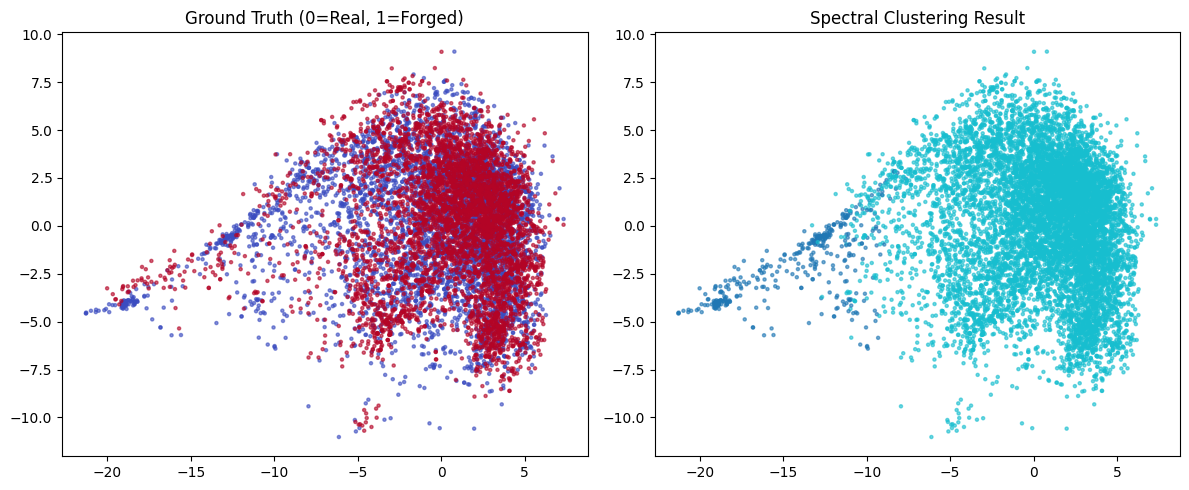

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import os

# Paths
OUT_ROOT = "/content/drive/MyDrive/CMFD_processed"
COMBINED_FEAT = os.path.join(OUT_ROOT, "dino_features_combined.npz")
CLUST_FILE = os.path.join(OUT_ROOT, "spectral_clusters_balanced.npy")

# Load
data = np.load(COMBINED_FEAT, allow_pickle=True)
X = data["feats"]
y_true = data["labels"]
labels = np.load(CLUST_FILE)   # 10k labels

# Balance again so dimensions match
n = min(np.sum(y_true==0), np.sum(y_true==1))
idx_real = np.where(y_true==0)[0][:n]
idx_forged = np.where(y_true==1)[0][:n]
idx = np.concatenate([idx_real, idx_forged])

X_bal = X[idx]
y_bal = y_true[idx]

print("Balanced features:", X_bal.shape, "Balanced labels:", y_bal.shape, "Clusters:", labels.shape)

# PCA to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_bal)

# Plot ground truth vs clusters
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(X_pca[:,0], X_pca[:,1], c=y_bal, cmap="coolwarm", s=5, alpha=0.6)
axs[0].set_title("Ground Truth (0=Real, 1=Forged)")

axs[1].scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap="tab10", s=5, alpha=0.6)
axs[1].set_title("Spectral Clustering Result")

plt.tight_layout()
plt.show()


Balanced set: (10000, 768) (10000,) (10000,)
Running t-SNE (this may take a few minutes)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


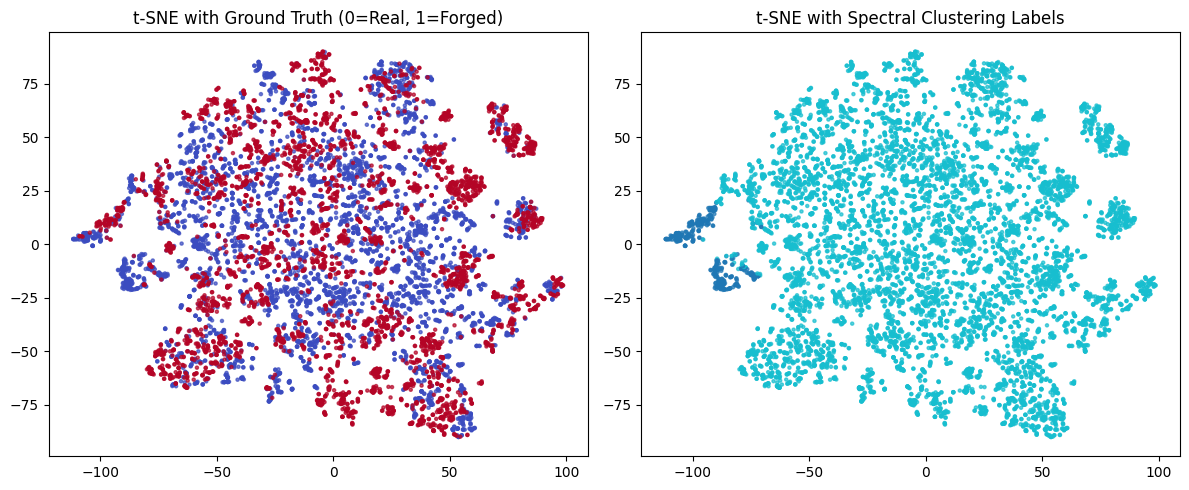

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import os

# Paths
OUT_ROOT = "/content/drive/MyDrive/CMFD_processed"
COMBINED_FEAT = os.path.join(OUT_ROOT, "dino_features_combined.npz")
CLUST_FILE = os.path.join(OUT_ROOT, "spectral_clusters_balanced.npy")

# Load
data = np.load(COMBINED_FEAT, allow_pickle=True)
X = data["feats"]
y_true = data["labels"]
labels = np.load(CLUST_FILE)   # clustered labels (10k samples)

# Match with balanced subset
n = min(np.sum(y_true==0), np.sum(y_true==1))
idx_real = np.where(y_true==0)[0][:n]
idx_forged = np.where(y_true==1)[0][:n]
idx = np.concatenate([idx_real, idx_forged])

X_bal = X[idx]
y_bal = y_true[idx]

print("Balanced set:", X_bal.shape, y_bal.shape, labels.shape)

# --- Run t-SNE (2D) ---
print("Running t-SNE (this may take a few minutes)...")
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_bal)

# --- Plot ground truth vs spectral clustering ---
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(X_tsne[:,0], X_tsne[:,1], c=y_bal, cmap="coolwarm", s=5, alpha=0.7)
axs[0].set_title("t-SNE with Ground Truth (0=Real, 1=Forged)")

axs[1].scatter(X_tsne[:,0], X_tsne[:,1], c=labels, cmap="tab10", s=5, alpha=0.7)
axs[1].set_title("t-SNE with Spectral Clustering Labels")

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import os

# ---------- CONFIG ----------
OUT_ROOT = "/content/drive/MyDrive/CMFD_processed"
COMBINED_FEAT = os.path.join(OUT_ROOT, "dino_features_combined.npz")
MODEL_PATH = os.path.join(OUT_ROOT, "cnn_classifier.h5")
# ----------------------------

# Load combined features
data = np.load(COMBINED_FEAT, allow_pickle=True)
X = data["feats"]   # (20000, 768)
y = data["labels"]  # (20000,)

print("Loaded features:", X.shape, "Labels:", y.shape, np.bincount(y))

# Train/Val/Test split (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

# Scale features (important for stable training)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Convert to TF tensors
X_train_tf = tf.convert_to_tensor(X_train, dtype=tf.float32)
X_val_tf = tf.convert_to_tensor(X_val, dtype=tf.float32)
X_test_tf = tf.convert_to_tensor(X_test, dtype=tf.float32)

# ---------- Build CNN/MLP Classifier ----------
model = tf.keras.Sequential([
    tf.keras.layers.Reshape((768,1), input_shape=(768,)),   # reshape for 1D conv
    tf.keras.layers.Conv1D(64, kernel_size=3, activation='relu'),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Conv1D(128, kernel_size=3, activation='relu'),
    tf.keras.layers.GlobalMaxPooling1D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

# ---------- Train ----------
history = model.fit(
    X_train_tf, y_train,
    validation_data=(X_val_tf, y_val),
    epochs=20,
    batch_size=64,
    verbose=1
)

# Save model
model.save(MODEL_PATH)
print("✅ Model saved ->", MODEL_PATH)

# ---------- Evaluate ----------
y_pred = (model.predict(X_test_tf) > 0.5).astype(int)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Loaded features: (20000, 768) Labels: (20000,) [ 5000 15000]
Train: (14000, 768) Val: (3000, 768) Test: (3000, 768)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_3 (Reshape)             │ (None, 768, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 766, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 383, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 381, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,601 (162.50 KB)

 Trainable params: 41,601 (162.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.7434 - loss: 0.5435 - val_accuracy: 0.7637 - val_loss: 0.4176
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7821 - loss: 0.3774 - val_accuracy: 0.7693 - val_loss: 0.4048
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7850 - loss: 0.3693 - val_accuracy: 0.8063 - val_loss: 0.3398
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8166 - loss: 0.3325 - val_accuracy: 0.8227 - val_loss: 0.3283
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8241 - loss: 0.3288 - val_accuracy: 0.8400 - val_loss: 0.3046
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8354 - loss: 0.3098 - val_accuracy: 0.8427 - val_loss: 0.3282
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8386 - loss: 0.3062 - val_accuracy: 0.8493 - val_loss: 0.2967
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8511 - loss: 0.2873 - val_accu

✅ Model saved -> /content/drive/MyDrive/CMFD_processed/cnn_classifier.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.71      0.73       750
           1       0.90      0.93      0.92      2250

    accuracy                           0.87      3000
   macro avg       0.83      0.82      0.82      3000
weighted avg       0.87      0.87      0.87      3000

Confusion Matrix:
 [[ 530  220]
 [ 166 2084]]


In [ ]:
from tensorflow import keras
import numpy as np
import os
from sklearn.metrics import classification_report

OUT_ROOT = "/content/drive/MyDrive/CMFD_processed"
MODEL_PATH = os.path.join(OUT_ROOT, "cnn_classifier.h5")

# Reload the model
model = keras.models.load_model(MODEL_PATH)

# 🔹 Recompile (needed after loading .h5)
model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Continue training from epoch 21 → 30
history2 = model.fit(
    X_train_tf, y_train,
    validation_data=(X_val_tf, y_val),
    epochs=30,            # extend to 30
    initial_epoch=20,     # continue after epoch 20
    batch_size=64,
    verbose=1
)

# Save again in new file
NEW_MODEL_PATH = os.path.join(OUT_ROOT, "cnn_classifier_epoch30.keras")
model.save(NEW_MODEL_PATH)
print("✅ Extended model saved ->", NEW_MODEL_PATH)

# Evaluate again on test set
y_pred = (model.predict(X_test_tf) > 0.5).astype(int)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Epoch 21/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9059 - loss: 0.2051 - val_accuracy: 0.8837 - val_loss: 0.2622
Epoch 22/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9235 - loss: 0.1834 - val_accuracy: 0.8760 - val_loss: 0.2748
Epoch 23/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9230 - loss: 0.1760 - val_accuracy: 0.8880 - val_loss: 0.2522
Epoch 24/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9036 - loss: 0.2094 - val_accuracy: 0.8880 - val_loss: 0.2586
Epoch 25/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9119 - loss: 0.1944 - val_accuracy: 0.8840 - val_loss: 0.2544
Epoch 26/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9217 - loss: 0.1793 - val_accuracy: 0.8773 - val_loss: 0.2707
Epoch 27/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9255 - loss: 0.1699 - val_accuracy: 0.8817 - val_loss: 0.2671
Epoch 28/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9264 - loss: 0.1684 - 

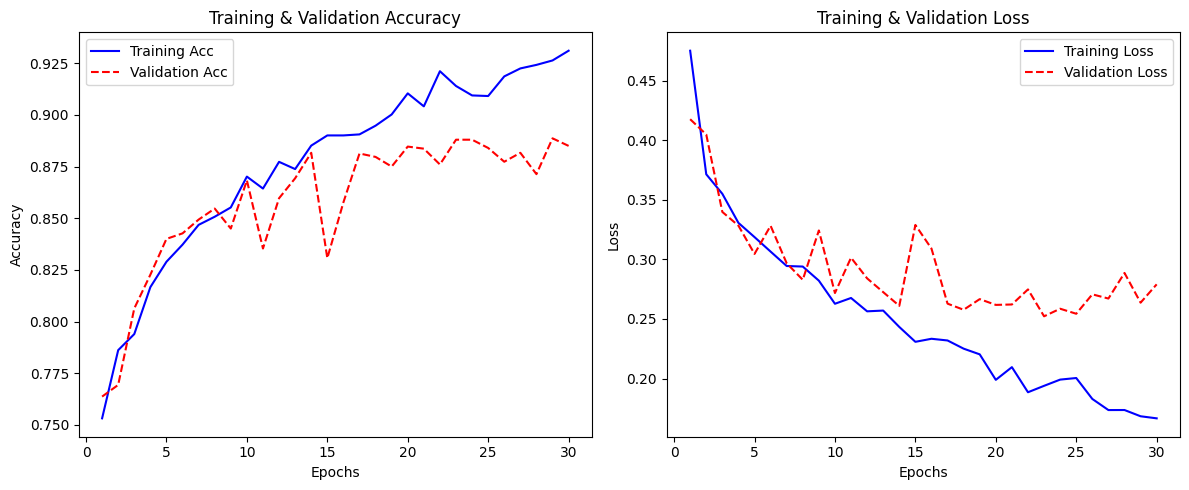

In [ ]:
import matplotlib.pyplot as plt

# Merge training curves from both runs
acc = history.history['accuracy'] + history2.history['accuracy']
val_acc = history.history['val_accuracy'] + history2.history['val_accuracy']
loss = history.history['loss'] + history2.history['loss']
val_loss = history.history['val_loss'] + history2.history['val_loss']

epochs = range(1, len(acc) + 1)

# --- Plot Accuracy ---
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, acc, 'b-', label='Training Acc')
plt.plot(epochs, val_acc, 'r--', label='Validation Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()

# --- Plot Loss ---
plt.subplot(1,2,2)
plt.plot(epochs, loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'r--', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# Continue training to 45 epochs total
history3 = model.fit(
    X_train_tf, y_train,
    validation_data=(X_val_tf, y_val),
    epochs=45,            # extend to 45
    initial_epoch=30,     # continue after epoch 30
    batch_size=64,
    verbose=1
)

# Save extended model
EXT_MODEL_PATH = os.path.join(OUT_ROOT, "cnn_classifier_epoch45.keras")
model.save(EXT_MODEL_PATH)
print("✅ Extended model saved ->", EXT_MODEL_PATH)

# Evaluate again on test set
y_pred = (model.predict(X_test_tf) > 0.5).astype(int)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Epoch 31/45
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9404 - loss: 0.1500 - val_accuracy: 0.8860 - val_loss: 0.3022
Epoch 32/45
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9330 - loss: 0.1584 - val_accuracy: 0.8450 - val_loss: 0.3552
Epoch 33/45
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9249 - loss: 0.1718 - val_accuracy: 0.8540 - val_loss: 0.2771
Epoch 34/45
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9334 - loss: 0.1539 - val_accuracy: 0.8840 - val_loss: 0.2621
Epoch 35/45
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9290 - loss: 0.1655 - val_accuracy: 0.8883 - val_loss: 0.2927
Epoch 36/45
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9458 - loss: 0.1334 - val_accuracy: 0.8887 - val_loss: 0.2596
Epoch 37/45
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9347 - loss: 0.1583 - val_accuracy: 0.8903 - val_loss: 0.2669
Epoch 38/45
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9416 - loss: 0.1405 - va

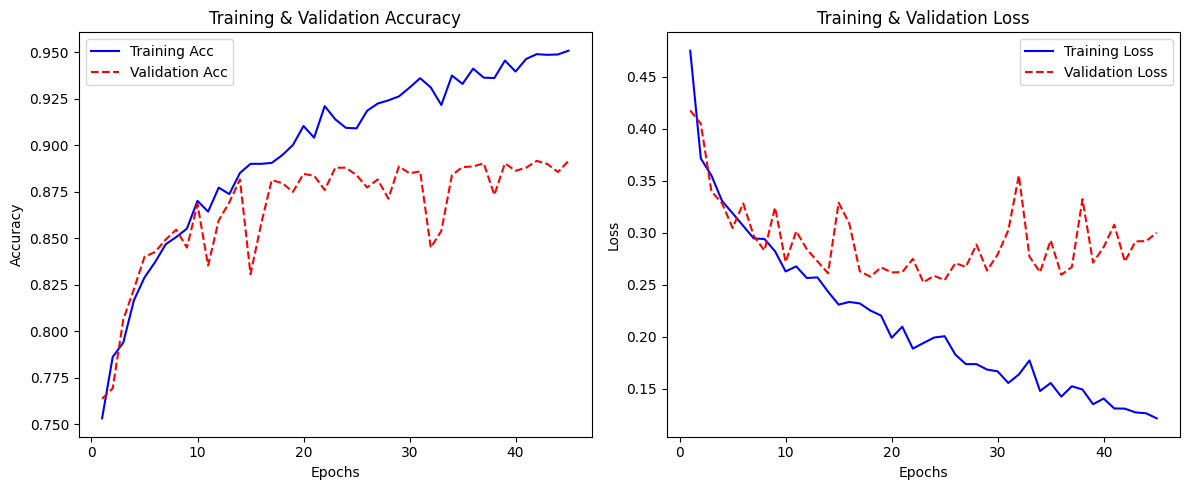

In [ ]:
import matplotlib.pyplot as plt

# Merge training histories
acc = history.history['accuracy'] + history2.history['accuracy'] + history3.history['accuracy']
val_acc = history.history['val_accuracy'] + history2.history['val_accuracy'] + history3.history['val_accuracy']
loss = history.history['loss'] + history2.history['loss'] + history3.history['loss']
val_loss = history.history['val_loss'] + history2.history['val_loss'] + history3.history['val_loss']

epochs = range(1, len(acc) + 1)

# --- Plot Accuracy ---
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, acc, 'b-', label='Training Acc')
plt.plot(epochs, val_acc, 'r--', label='Validation Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()

# --- Plot Loss ---
plt.subplot(1,2,2)
plt.plot(epochs, loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'r--', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()


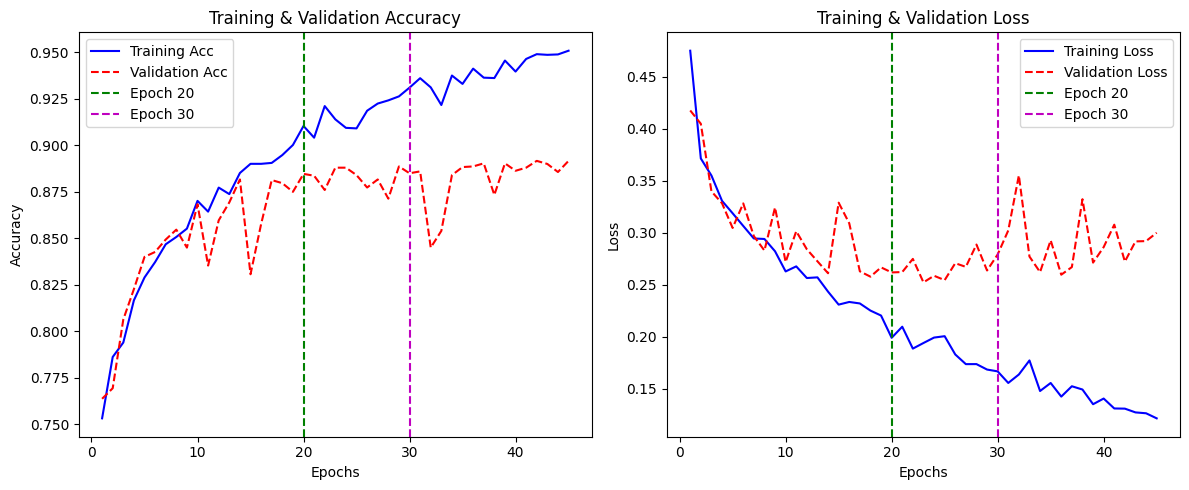

In [ ]:
import matplotlib.pyplot as plt

# Merge training histories (20 + 10 + 15)
acc = history.history['accuracy'] + history2.history['accuracy'] + history3.history['accuracy']
val_acc = history.history['val_accuracy'] + history2.history['val_accuracy'] + history3.history['val_accuracy']
loss = history.history['loss'] + history2.history['loss'] + history3.history['loss']
val_loss = history.history['val_loss'] + history2.history['val_loss'] + history3.history['val_loss']

epochs = range(1, len(acc) + 1)

# --- Plot Accuracy ---
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, acc, 'b-', label='Training Acc')
plt.plot(epochs, val_acc, 'r--', label='Validation Acc')

# Markers for stage boundaries
plt.axvline(x=20, color='g', linestyle='--', label='Epoch 20')
plt.axvline(x=30, color='m', linestyle='--', label='Epoch 30')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()

# --- Plot Loss ---
plt.subplot(1,2,2)
plt.plot(epochs, loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'r--', label='Validation Loss')

# Markers
plt.axvline(x=20, color='g', linestyle='--', label='Epoch 20')
plt.axvline(x=30, color='m', linestyle='--', label='Epoch 30')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import os

# Paths
OUT_ROOT = "/content/drive/MyDrive/CMFD_processed"
CHECKPOINT_DIR = os.path.join(OUT_ROOT, "cnn_checkpoints")
BEST_MODEL_PATH = os.path.join(OUT_ROOT, "cnn_classifier_best.keras")
LAST_MODEL_PATH = os.path.join(OUT_ROOT, "cnn_classifier_last.keras")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
checkpoint_cb = ModelCheckpoint(
    filepath=os.path.join(CHECKPOINT_DIR, "epoch_{epoch:02d}_valacc_{val_accuracy:.4f}.keras"),
    save_best_only=False,  # save every epoch
    save_weights_only=False,
    verbose=1
)
best_cb = ModelCheckpoint(BEST_MODEL_PATH, monitor="val_accuracy", save_best_only=True, verbose=1)
last_cb = ModelCheckpoint(LAST_MODEL_PATH, save_best_only=False, verbose=1)

# Build model (tuned params)
tuned_model = tf.keras.Sequential([
    tf.keras.layers.Reshape((768,1), input_shape=(768,)),
    tf.keras.layers.Conv1D(64, kernel_size=3, activation='relu'),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Conv1D(128, kernel_size=3, activation='relu'),
    tf.keras.layers.GlobalMaxPooling1D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),   # tuned dropout
    tf.keras.layers.Dense(1, activation='sigmoid')
])

tuned_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),  # tuned LR
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

# Train with checkpointing
history_tuned = tuned_model.fit(
    X_train_tf, y_train,
    validation_data=(X_val_tf, y_val),
    epochs=60,
    batch_size=128,
    callbacks=[early_stop, reduce_lr, checkpoint_cb, best_cb, last_cb],
    verbose=1
)

print("✅ Training complete")
print("Best model saved ->", BEST_MODEL_PATH)
print("Last model saved ->", LAST_MODEL_PATH)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7193 - loss: 0.6339
Epoch 1: saving model to /content/drive/MyDrive/CMFD_processed/cnn_checkpoints/epoch_01_valacc_0.7500.keras

Epoch 1: val_accuracy improved from -inf to 0.75000, saving model to /content/drive/MyDrive/CMFD_processed/cnn_classifier_best.keras

Epoch 1: saving model to /content/drive/MyDrive/CMFD_processed/cnn_classifier_last.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.7195 - loss: 0.6337 - val_accuracy: 0.7500 - val_loss: 0.5784 - learning_rate: 1.0000e-04
Epoch 2/60
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7467 - loss: 0.5721
Epoch 2: saving model to /content/drive/MyDrive/CMFD_processed/cnn_checkpoints/epoch_02_valacc_0.7500.keras

Epoch 2: val_accuracy did not improve from 0.75000

Epoch 2: saving model to /content/drive/MyDrive/CMFD_processed/cnn_classifier_last.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7468 - loss: 0.5718 - val_accuracy: 0.750

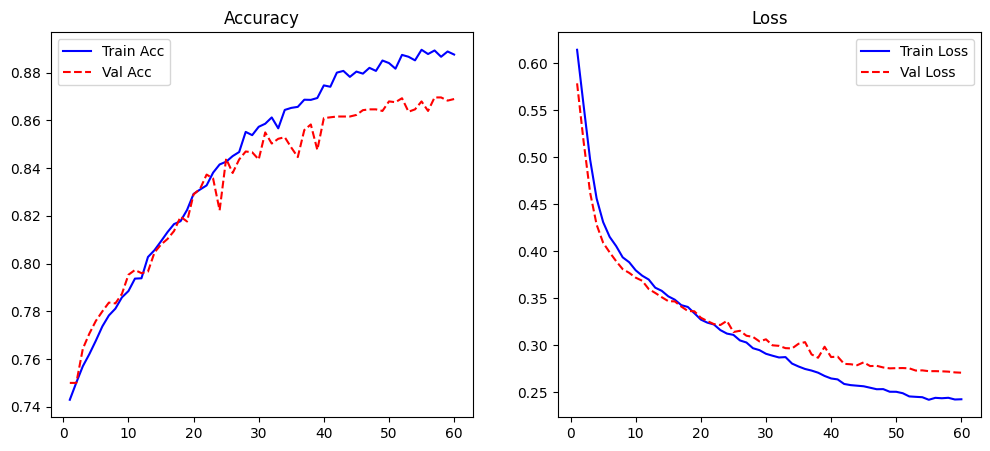

In [ ]:
import matplotlib.pyplot as plt

acc = history_tuned.history['accuracy']
val_acc = history_tuned.history['val_accuracy']
loss = history_tuned.history['loss']
val_loss = history_tuned.history['val_loss']

epochs = range(1, len(acc)+1)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, acc, 'b-', label="Train Acc")
plt.plot(epochs, val_acc, 'r--', label="Val Acc")
plt.legend(); plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(epochs, loss, 'b-', label="Train Loss")
plt.plot(epochs, val_loss, 'r--', label="Val Loss")
plt.legend(); plt.title("Loss")

plt.show()


In [ ]:
from tensorflow import keras
best_model = keras.models.load_model("/content/drive/MyDrive/CMFD_processed/cnn_classifier_best.keras")

test_loss, test_acc = best_model.evaluate(X_test_tf, y_test, verbose=1)
print(f"✅ Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")


94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8530 - loss: 0.2926
✅ Test Accuracy: 0.8540, Test Loss: 0.2907


In [ ]:
import os
from tensorflow import keras

# === Paths ===
checkpoint_dir = "/content/drive/MyDrive/CMFD_processed/cnn_checkpoints"
best_model_path = "/content/drive/MyDrive/CMFD_processed/cnn_classifier_best.keras"
last_model_path = "/content/drive/MyDrive/CMFD_processed/cnn_classifier_last.keras"

# === Find latest checkpoint ===
checkpoint_files = [f for f in os.listdir(checkpoint_dir) if f.endswith(".keras")]
if checkpoint_files:
    checkpoint_files.sort()  # ensure chronological order
    latest_checkpoint = os.path.join(checkpoint_dir, checkpoint_files[-1])
    print(f"✅ Found latest checkpoint: {latest_checkpoint}")
    model = keras.models.load_model(latest_checkpoint)
    initial_epoch = int(checkpoint_files[-1].split("_")[1])  # epoch number
else:
    print("⚠️ No checkpoint found, training from scratch...")
    model = create_model()  # <-- use your model definition here
    initial_epoch = 0

# === Compile model again (required after load) ===
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# === Callbacks ===
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(checkpoint_dir, "epoch_{epoch:02d}_valacc_{val_accuracy:.4f}.keras"),
        save_best_only=False,
        save_weights_only=False,
        monitor="val_accuracy",
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=best_model_path,
        save_best_only=True,
        save_weights_only=False,
        monitor="val_accuracy",
        mode="max",
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=last_model_path,
        save_best_only=False,
        save_weights_only=False,
        monitor="val_accuracy",
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, verbose=1
    )
]

# === Resume Training ===
history_resume = model.fit(
    X_train_tf, y_train,
    validation_data=(X_val_tf, y_val),
    epochs=80,                # extend training up to 80
    initial_epoch=initial_epoch,
    callbacks=callbacks,
    batch_size=64
)


✅ Found latest checkpoint: /content/drive/MyDrive/CMFD_processed/cnn_checkpoints/epoch_60_valacc_0.8690.keras
Epoch 61/80
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8850 - loss: 0.2440
Epoch 61: saving model to /content/drive/MyDrive/CMFD_processed/cnn_checkpoints/epoch_61_valacc_0.8670.keras

Epoch 61: val_accuracy improved from -inf to 0.86700, saving model to /content/drive/MyDrive/CMFD_processed/cnn_classifier_best.keras

Epoch 61: saving model to /content/drive/MyDrive/CMFD_processed/cnn_classifier_last.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.8850 - loss: 0.2440 - val_accuracy: 0.8670 - val_loss: 0.2771 - learning_rate: 1.0000e-04
Epoch 62/80
216/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8939 - loss: 0.2353
Epoch 62: saving model to /content/drive/MyDrive/CMFD_processed/cnn_checkpoints/epoch_62_valacc_0.8683.keras

Epoch 62: val_accuracy improved from 0.86700 to 0.86833, saving model to /content/drive/MyDrive/CMFD_processed/cnn_classif

In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Paths
checkpoint_dir = "/content/drive/MyDrive/CMFD_processed/cnn_checkpoints"
best_model_path = "/content/drive/MyDrive/CMFD_processed/cnn_classifier_best.keras"
last_model_path = "/content/drive/MyDrive/CMFD_processed/cnn_classifier_last.keras"

# Callbacks
checkpoint_cb = ModelCheckpoint(
    filepath=checkpoint_dir + "/epoch_{epoch:02d}_valacc_{val_accuracy:.4f}.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=False,
    save_weights_only=False,
    verbose=1
)

best_cb = ModelCheckpoint(
    filepath=best_model_path,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

last_cb = ModelCheckpoint(
    filepath=last_model_path,
    monitor="val_accuracy",
    mode="max",
    save_best_only=False,
    verbose=1
)

earlystop_cb = EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=5,      # Stop if no improvement for 5 epochs
    restore_best_weights=True,
    verbose=1
)

lr_cb = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

# Resume training
history3 = model.fit(
    X_train_tf, y_train,
    validation_data=(X_val_tf, y_val),
    epochs=100,          # max cap
    initial_epoch=80,    # continue from last
    batch_size=64,
    callbacks=[checkpoint_cb, best_cb, last_cb, earlystop_cb, lr_cb]
)


Epoch 81/100
215/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9106 - loss: 0.2019
Epoch 81: saving model to /content/drive/MyDrive/CMFD_processed/cnn_checkpoints/epoch_81_valacc_0.8833.keras

Epoch 81: val_accuracy improved from -inf to 0.88333, saving model to /content/drive/MyDrive/CMFD_processed/cnn_classifier_best.keras

Epoch 81: saving model to /content/drive/MyDrive/CMFD_processed/cnn_classifier_last.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9106 - loss: 0.2019 - val_accuracy: 0.8833 - val_loss: 0.2581 - learning_rate: 1.0000e-04
Epoch 82/100
213/219 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9121 - loss: 0.2091
Epoch 82: saving model to /content/drive/MyDrive/CMFD_processed/cnn_checkpoints/epoch_82_valacc_0.8780.keras

Epoch 82: val_accuracy did not improve from 0.88333

Epoch 82: saving model to /content/drive/MyDrive/CMFD_processed/cnn_classifier_last.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9121 - loss: 0.2089 - val_accurac

In [ ]:
from tensorflow import keras
import os

# --- Paths ---
CHECKPOINT_DIR = "/content/drive/MyDrive/CMFD_processed/cnn_checkpoints"
LAST_MODEL = os.path.join(CHECKPOINT_DIR, "epoch_90_valacc_0.8843.keras")

# --- Reload last model ---
model = keras.models.load_model(LAST_MODEL)

# Recompile (important after reload)
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4),
              loss="binary_crossentropy",
              metrics=["accuracy"])

# --- Callbacks ---
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(CHECKPOINT_DIR, "epoch_{epoch:02d}_valacc_{val_accuracy:.4f}.keras"),
    save_best_only=True,
    monitor="val_accuracy",
    mode="max",
    verbose=1
)

last_cb = keras.callbacks.ModelCheckpoint(
    filepath="/content/drive/MyDrive/CMFD_processed/cnn_classifier_last.keras",
    save_best_only=False,
    verbose=1
)

earlystop_cb = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=5,  # stop if no improvement in 5 epochs
    restore_best_weights=True,
    verbose=1
)

reduce_lr_cb = keras.callbacks.ReduceLROnPlateau(
    monitor="val_accuracy",
    factor=0.5,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

# --- Continue training for 10 epochs (91–100) ---
history3 = model.fit(
    X_train_tf, y_train,
    validation_data=(X_val_tf, y_val),
    epochs=100,              # train up to epoch 100
    initial_epoch=90,        # continue from epoch 90
    callbacks=[checkpoint_cb, last_cb, earlystop_cb, reduce_lr_cb],
    batch_size=32,
    verbose=1
)


Epoch 91/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9146 - loss: 0.1896
Epoch 91: val_accuracy improved from -inf to 0.88433, saving model to /content/drive/MyDrive/CMFD_processed/cnn_checkpoints/epoch_91_valacc_0.8843.keras

Epoch 91: saving model to /content/drive/MyDrive/CMFD_processed/cnn_classifier_last.keras
438/438 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9146 - loss: 0.1896 - val_accuracy: 0.8843 - val_loss: 0.2539 - learning_rate: 1.0000e-04
Epoch 92/100
437/438 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9188 - loss: 0.1880
Epoch 92: val_accuracy improved from 0.88433 to 0.88500, saving model to /content/drive/MyDrive/CMFD_processed/cnn_checkpoints/epoch_92_valacc_0.8850.keras

Epoch 92: saving model to /content/drive/MyDrive/CMFD_processed/cnn_classifier_last.keras
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9188 - loss: 0.1880 - val_accuracy: 0.8850 - val_loss: 0.2536 - learning_rate: 1.0000e-04
Epoch 93/100
436/438 ━━━━━━━━━━━━━━━━━━

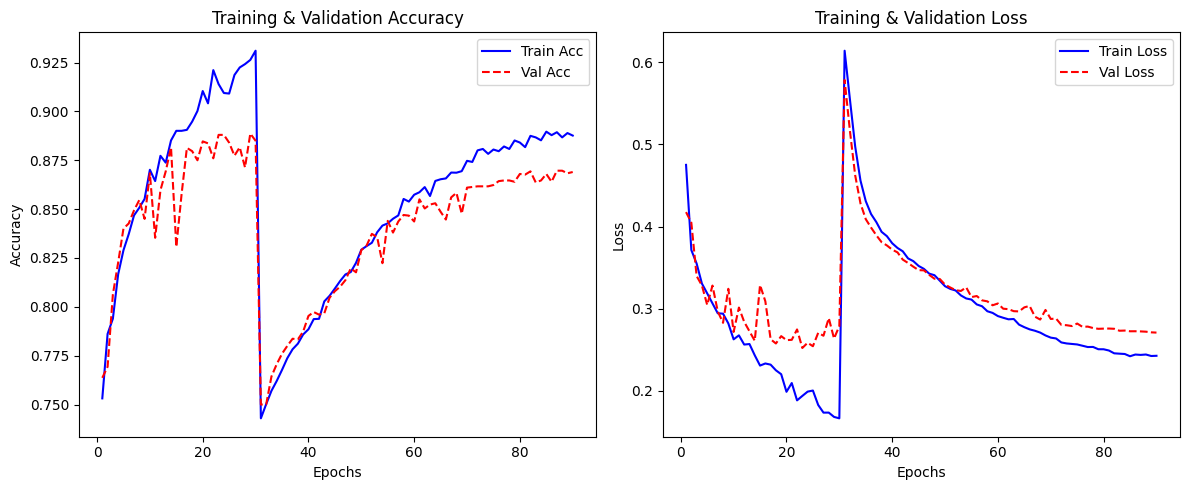

In [ ]:
import matplotlib.pyplot as plt

# --- Merge all histories ---
acc = history.history['accuracy'] + history2.history['accuracy'] + history_tuned.history['accuracy']
val_acc = history.history['val_accuracy'] + history2.history['val_accuracy'] + history_tuned.history['val_accuracy']
loss = history.history['loss'] + history2.history['loss'] + history_tuned.history['loss']
val_loss = history.history['val_loss'] + history2.history['val_loss'] + history_tuned.history['val_loss']

epochs = range(1, len(acc)+1)

# --- Plot ---
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs, acc, 'b-', label="Train Acc")
plt.plot(epochs, val_acc, 'r--', label="Val Acc")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(epochs, loss, 'b-', label="Train Loss")
plt.plot(epochs, val_loss, 'r--', label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()


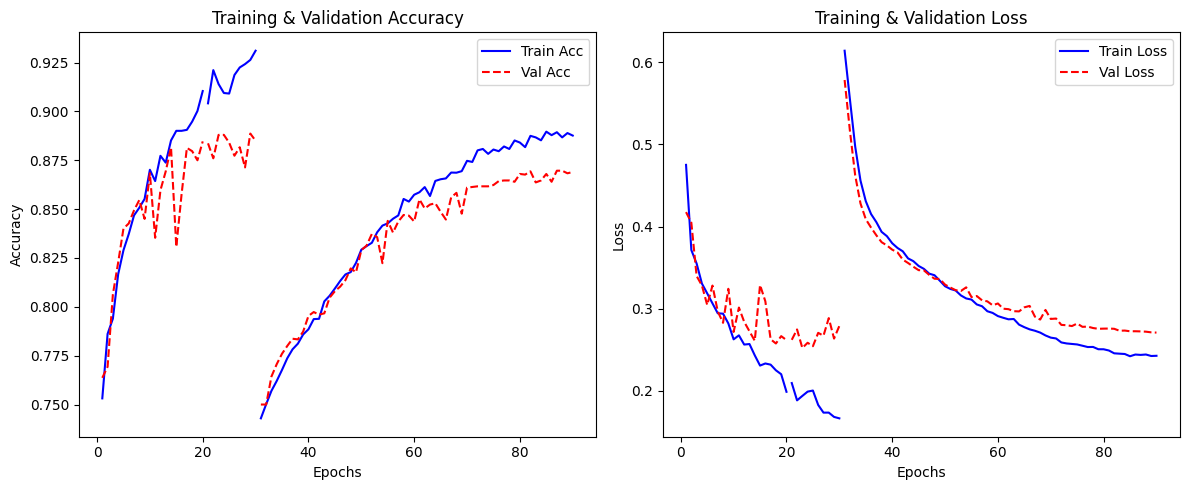

In [ ]:
import matplotlib.pyplot as plt

# Offsets: history (1-20), history2 (21-45), history_tuned (46-100)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs1 = range(1, len(acc)+1)

acc2 = history2.history['accuracy']
val_acc2 = history2.history['val_accuracy']
loss2 = history2.history['loss']
val_loss2 = history2.history['val_loss']
epochs2 = range(len(acc)+1, len(acc)+len(acc2)+1)

acc3 = history_tuned.history['accuracy']
val_acc3 = history_tuned.history['val_accuracy']
loss3 = history_tuned.history['loss']
val_loss3 = history_tuned.history['val_loss']
epochs3 = range(len(acc)+len(acc2)+1, len(acc)+len(acc2)+len(acc3)+1)

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs1, acc, 'b-')
plt.plot(epochs1, val_acc, 'r--')
plt.plot(epochs2, acc2, 'b-')
plt.plot(epochs2, val_acc2, 'r--')
plt.plot(epochs3, acc3, 'b-')
plt.plot(epochs3, val_acc3, 'r--')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend(["Train Acc","Val Acc"])

# Loss
plt.subplot(1,2,2)
plt.plot(epochs1, loss, 'b-')
plt.plot(epochs1, val_loss, 'r--')
plt.plot(epochs2, loss2, 'b-')
plt.plot(epochs2, val_loss2, 'r--')
plt.plot(epochs3, loss3, 'b-')
plt.plot(epochs3, val_loss3, 'r--')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend(["Train Loss","Val Loss"])

plt.tight_layout()
plt.show()


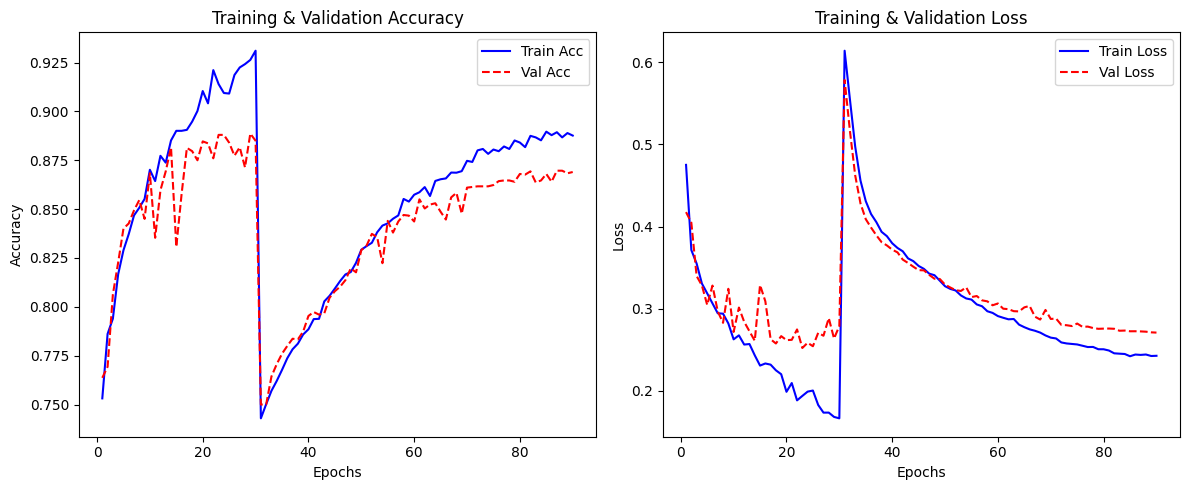

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Concatenate all runs
acc = np.concatenate([
    history.history['accuracy'],
    history2.history['accuracy'],
    history_tuned.history['accuracy']
])
val_acc = np.concatenate([
    history.history['val_accuracy'],
    history2.history['val_accuracy'],
    history_tuned.history['val_accuracy']
])
loss = np.concatenate([
    history.history['loss'],
    history2.history['loss'],
    history_tuned.history['loss']
])
val_loss = np.concatenate([
    history.history['val_loss'],
    history2.history['val_loss'],
    history_tuned.history['val_loss']
])

epochs = range(1, len(acc) + 1)

# Plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, acc, 'b-', label="Train Acc")
plt.plot(epochs, val_acc, 'r--', label="Val Acc")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, loss, 'b-', label="Train Loss")
plt.plot(epochs, val_loss, 'r--', label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()


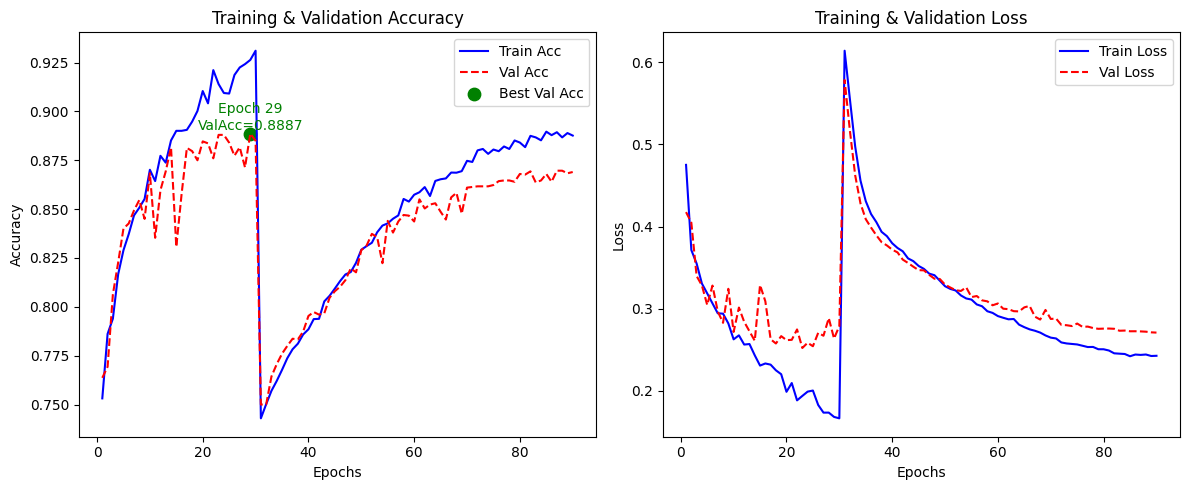

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Merge all histories ---
acc = np.concatenate([
    history.history['accuracy'],
    history2.history['accuracy'],
    history_tuned.history['accuracy']
])
val_acc = np.concatenate([
    history.history['val_accuracy'],
    history2.history['val_accuracy'],
    history_tuned.history['val_accuracy']
])
loss = np.concatenate([
    history.history['loss'],
    history2.history['loss'],
    history_tuned.history['loss']
])
val_loss = np.concatenate([
    history.history['val_loss'],
    history2.history['val_loss'],
    history_tuned.history['val_loss']
])

epochs = range(1, len(acc) + 1)

# --- Find best validation accuracy ---
best_epoch = np.argmax(val_acc) + 1
best_val_acc = np.max(val_acc)

# --- Plot ---
plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(epochs, acc, 'b-', label="Train Acc")
plt.plot(epochs, val_acc, 'r--', label="Val Acc")
plt.scatter(best_epoch, best_val_acc, color='green', s=80, label="Best Val Acc")
plt.text(best_epoch, best_val_acc+0.002,
         f"Epoch {best_epoch}\nValAcc={best_val_acc:.4f}",
         ha='center', color='green')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(epochs, loss, 'b-', label="Train Loss")
plt.plot(epochs, val_loss, 'r--', label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Classification Report:
              precision    recall  f1-score   support

           0     0.7626    0.7880    0.7751       750
           1     0.9285    0.9182    0.9234      2250

    accuracy                         0.8857      3000
   macro avg     0.8456    0.8531    0.8492      3000
weighted avg     0.8870    0.8857    0.8863      3000



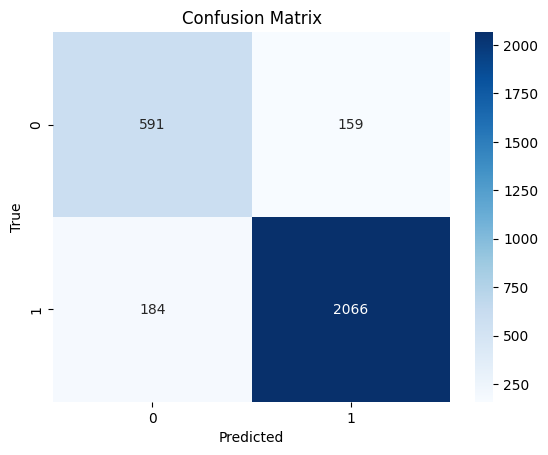

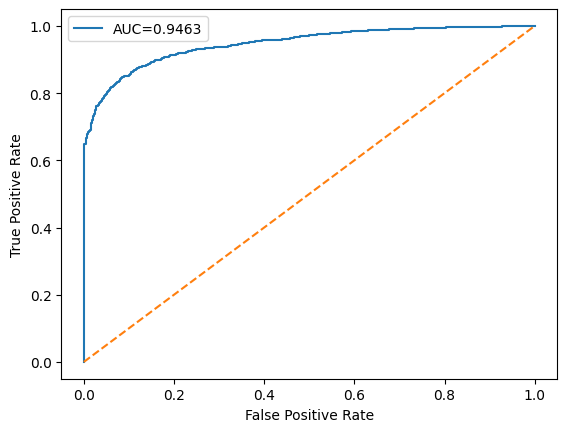

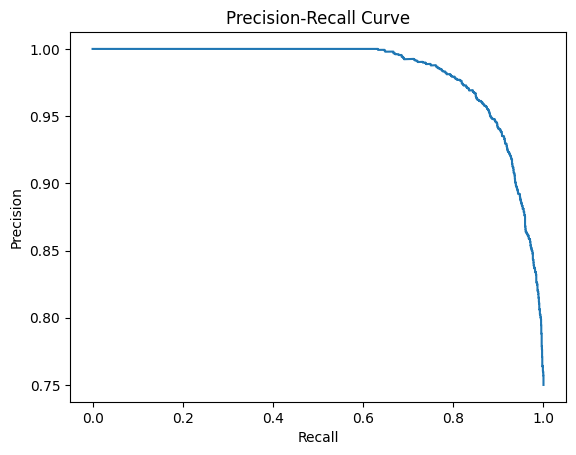

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
import seaborn as sns

# --- Predictions ---
y_pred = best_model.predict(X_val).ravel()   # shape (N,)
y_pred_classes = (y_pred > 0.5).astype(int)  # threshold

# --- Classification Report ---
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, digits=4))

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_true, y_pred)  # use raw probabilities
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC={roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# --- Precision-Recall Curve ---
prec, rec, _ = precision_recall_curve(y_true, y_pred)
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Classification Report:
              precision    recall  f1-score   support

           0     0.7626    0.7880    0.7751       750
           1     0.9285    0.9182    0.9234      2250

    accuracy                         0.8857      3000
   macro avg     0.8456    0.8531    0.8492      3000
weighted avg     0.8870    0.8857    0.8863      3000



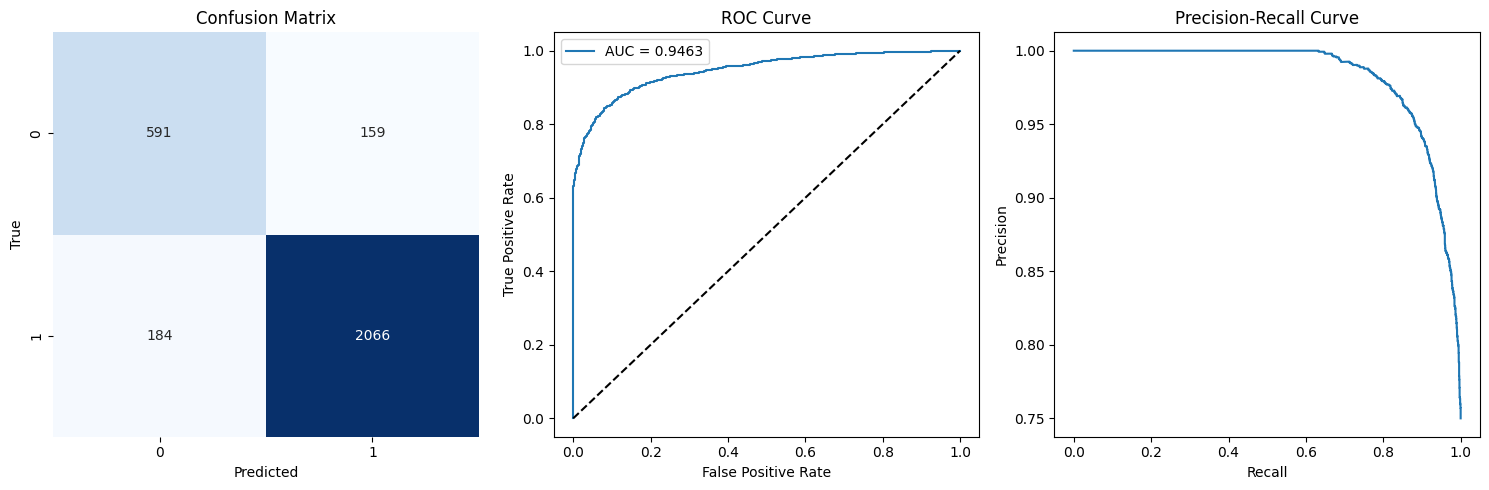

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve
)

# --- Predict probabilities ---
y_pred = best_model.predict(X_val).ravel()  # shape (N,)
y_pred_classes = (y_pred > 0.5).astype(int)  # threshold at 0.5

# --- Classification Report ---
print("\nClassification Report:")
print(classification_report(y_val, y_pred_classes, digits=4))

# --- Confusion Matrix ---
cm = confusion_matrix(y_val, y_pred_classes)

plt.figure(figsize=(15,5))

# 1. Confusion Matrix
plt.subplot(1,3,1)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_pred)
roc_auc = auc(fpr, tpr)

plt.subplot(1,3,2)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

# 3. Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_val, y_pred)
plt.subplot(1,3,3)
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.tight_layout()
plt.show()


94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


TypeError: Invalid shape (768,) for image data

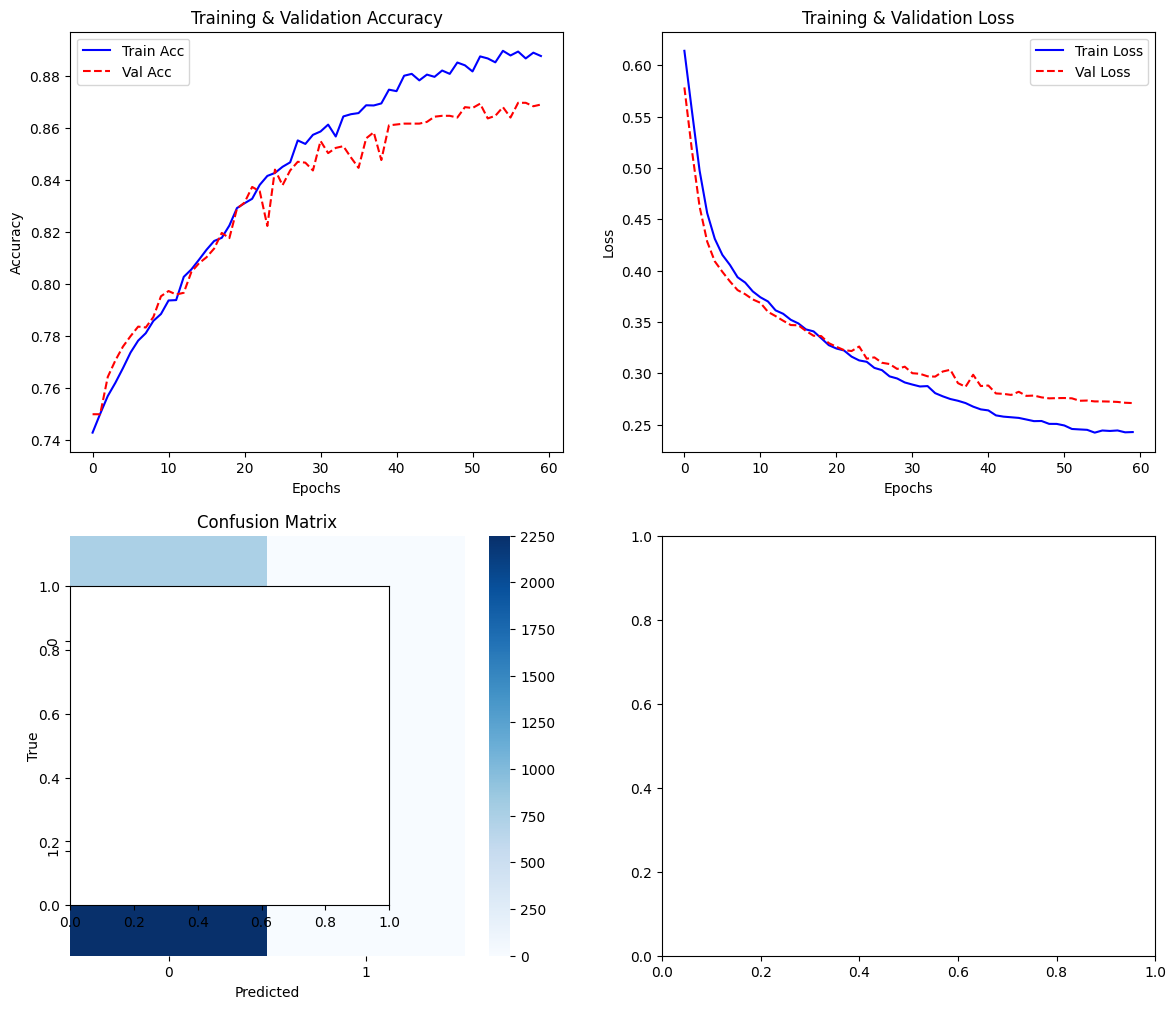

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# ---- Panel A: Training Curves ----
fig, axs = plt.subplots(2, 2, figsize=(14,12))

# Accuracy
axs[0,0].plot(history_tuned.history['accuracy'], 'b-', label='Train Acc')
axs[0,0].plot(history_tuned.history['val_accuracy'], 'r--', label='Val Acc')
axs[0,0].set_title("Training & Validation Accuracy")
axs[0,0].set_xlabel("Epochs"); axs[0,0].set_ylabel("Accuracy")
axs[0,0].legend()

# Loss
axs[0,1].plot(history_tuned.history['loss'], 'b-', label='Train Loss')
axs[0,1].plot(history_tuned.history['val_loss'], 'r--', label='Val Loss')
axs[0,1].set_title("Training & Validation Loss")
axs[0,1].set_xlabel("Epochs"); axs[0,1].set_ylabel("Loss")
axs[0,1].legend()

# ---- Panel B: Confusion Matrix ----
y_pred = best_model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_val, y_pred_classes)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axs[1,0])
axs[1,0].set_xlabel("Predicted"); axs[1,0].set_ylabel("True")
axs[1,0].set_title("Confusion Matrix")

# ---- Panel C: Example CoMoFoD detections ----
test_imgs = X_val[:6]   # replace with your CoMoFoD test images
preds = best_model.predict(test_imgs)

for i, img in enumerate(test_imgs):
    ax = plt.subplot(2, 3, i+4)  # bottom row
    ax.imshow(img.astype(np.uint8))

    # Dummy mask for illustration (replace with predicted mask if available)
    mask = np.random.randint(0,2,img.shape[:2])
    overlay = img.copy()
    overlay[mask==1] = [0,255,0]   # tampered area = green

    ax.imshow(overlay, alpha=0.5)
    ax.axis('off')
    ax.set_title(f"Sample {i+1}")

plt.tight_layout()
plt.show()


94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Classification Report:
              precision    recall  f1-score   support

           0     0.7626    0.7880    0.7751       750
           1     0.9285    0.9182    0.9234      2250

    accuracy                         0.8857      3000
   macro avg     0.8456    0.8531    0.8492      3000
weighted avg     0.8870    0.8857    0.8863      3000



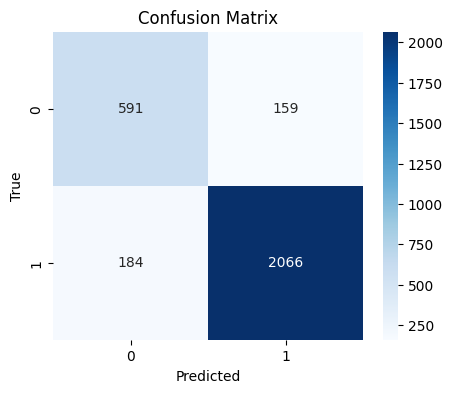

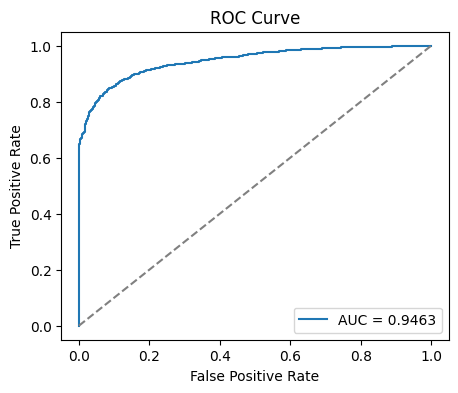

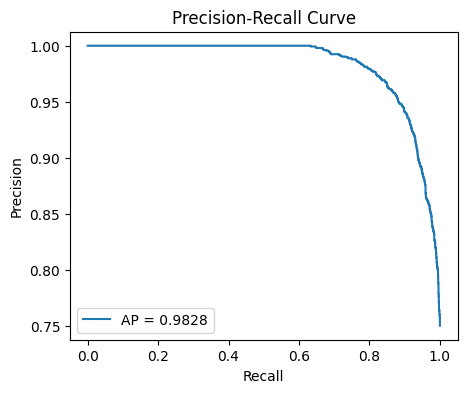

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score

# --- Get predictions ---
y_pred_prob = best_model.predict(X_val)  # probabilities in [0,1]
y_pred_classes = (y_pred_prob > 0.5).astype("int32")  # threshold at 0.5
y_true = y_val  # already 0/1 labels

# --- Classification Report ---
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, digits=4))

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# --- Precision-Recall Curve ---
precision, recall, _ = precision_recall_curve(y_true, y_pred_prob)
avg_prec = average_precision_score(y_true, y_pred_prob)

plt.figure(figsize=(5,4))
plt.plot(recall, precision, label=f"AP = {avg_prec:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


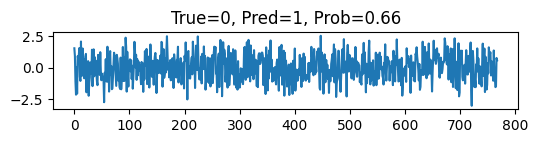

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


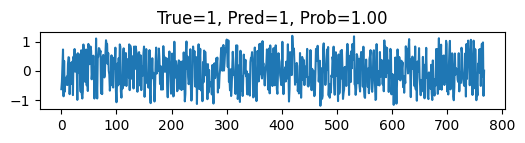

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


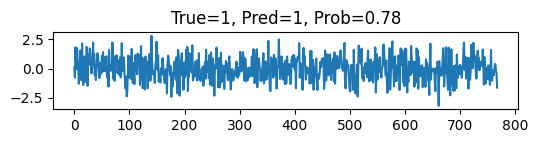

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


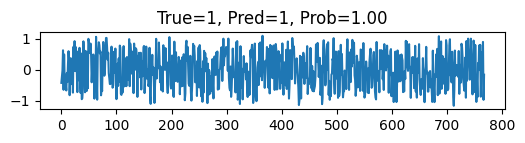

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


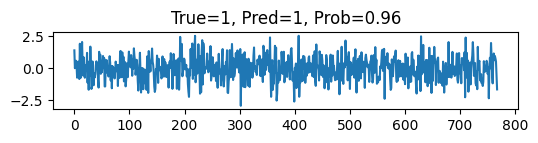

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Take a few feature vectors and show predictions
sample_idxs = np.random.choice(len(X_val_tf), 5, replace=False)

for idx in sample_idxs:
    feature_vec = X_val_tf[idx]
    true_label = y_val[idx]
    pred_prob = best_model.predict(feature_vec[np.newaxis, :])[0][0]
    pred_class = int(pred_prob > 0.5)

    plt.figure(figsize=(6,1))
    plt.plot(feature_vec)  # just show the feature vector values
    plt.title(f"True={true_label}, Pred={pred_class}, Prob={pred_prob:.2f}")
    plt.show()


In [ ]:
import cv2, os, numpy as np, matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import img_to_array

# Path to your dataset (change folder as needed)
DATASET_PATH = "/content/drive/MyDrive/CMFD_dataset/test_images"

# Pick a random image
fname = np.random.choice(os.listdir(DATASET_PATH))
img_path = os.path.join(DATASET_PATH, fname)

# Load and show
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img); plt.title(f"Random test image: {fname}"); plt.axis("off")
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/CMFD_dataset/test_images'

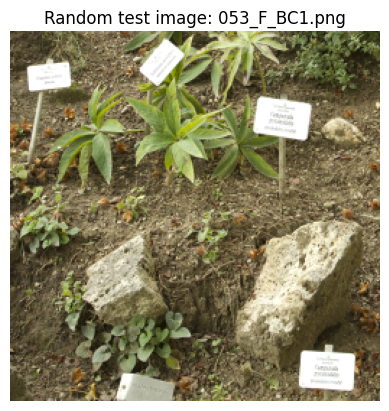

In [ ]:
import cv2, os, numpy as np, matplotlib.pyplot as plt

# Correct dataset path
DATASET_PATH = "/content/drive/MyDrive/CMFD_processed/images"

# Pick a random image
fname = np.random.choice(os.listdir(DATASET_PATH))
img_path = os.path.join(DATASET_PATH, fname)

# Load image
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title(f"Random test image: {fname}")
plt.axis("off")
plt.show()


In [ ]:
PATCH_SIZE = 64

def extract_patches(image, patch_size=64):
    patches, coords = [], []
    h, w, _ = image.shape
    for y in range(0, h-patch_size+1, patch_size):
        for x in range(0, w-patch_size+1, patch_size):
            patch = image[y:y+patch_size, x:x+patch_size]
            patches.append(patch)
            coords.append((x,y))
    return np.array(patches), coords

# Extract patches
patches, coords = extract_patches(img, PATCH_SIZE)
patches_norm = patches.astype("float32") / 255.0

# Run through trained model
pred_probs = best_model.predict(patches_norm, verbose=0)
pred_classes = (pred_probs > 0.5).astype(int).flatten()


ValueError: Exception encountered when calling Sequential.call().

[1mCannot take the length of shape with unknown rank.[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=<unknown>, dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [ ]:
import os, cv2, numpy as np, matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import tensorflow as tf
from skimage.util import view_as_windows

# -------------------------------
# Load trained CNN classifier
# -------------------------------
cnn_model = load_model("/content/drive/MyDrive/CMFD_processed/cnn_classifier_best.keras")

# -------------------------------
# Helper: extract 64x64 patches
# -------------------------------
def extract_patches(img, patch_size=64, stride=64):
    """Extract non-overlapping 64x64 patches from an image"""
    patches = view_as_windows(img, (patch_size, patch_size, 3), step=stride)
    patches = patches.reshape(-1, patch_size, patch_size, 3)
    return patches

# -------------------------------
# Pick random image from folder
# -------------------------------
img_dir = "/content/drive/MyDrive/CMFD_processed/images/"
fname = np.random.choice(os.listdir(img_dir))
img_path = os.path.join(img_dir, fname)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print("Picked:", fname, "->", img.shape)

# -------------------------------
# Preprocess patches
# -------------------------------
patches = extract_patches(img, 64, 64)
patches_norm = patches.astype("float32") / 255.0

# Predict
pred_probs = cnn_model.predict(patches_norm, verbose=0)
pred_classes = (pred_probs > 0.5).astype(int).flatten()

print("Predicted forged patches:", np.sum(pred_classes))

# -------------------------------
# Reconstruct mask
# -------------------------------
h, w, _ = img.shape
mask = np.zeros((h, w), dtype=np.uint8)

idx = 0
for y in range(0, h, 64):
    for x in range(0, w, 64):
        if idx < len(pred_classes) and pred_classes[idx] == 1:
            mask[y:y+64, x:x+64] = 255
        idx += 1

# -------------------------------
# Show results
# -------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img); axes[0].set_title("Original Image"); axes[0].axis("off")
axes[1].imshow(mask, cmap="gray"); axes[1].set_title("Prediction Mask"); axes[1].axis("off")
axes[2].imshow(img); axes[2].imshow(mask, cmap="jet", alpha=0.5); axes[2].set_title("Overlay"); axes[2].axis("off")
plt.show()


Picked: 009_F_JC6.png -> (256, 256, 3)


ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(16, 64, 64, 3), dtype=float32). Expected shape (None, 768), but input has incompatible shape (16, 64, 64, 3)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(16, 64, 64, 3), dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

✅ DINOv3 loaded successfully from Drive
Picked: 165_O.png -> (256, 256, 3)
Predicted forged patches: 0


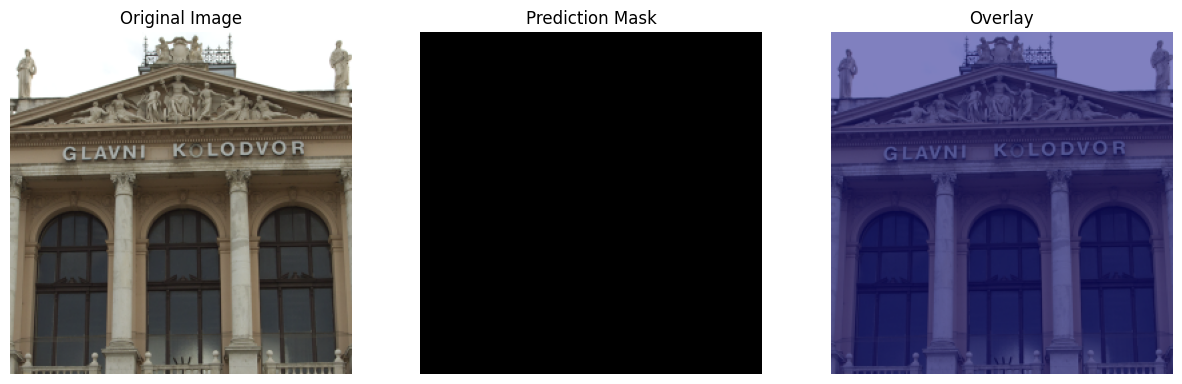

In [ ]:
import os, cv2, numpy as np, matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import torch
import torch.nn as nn
from torchvision import transforms

# -------------------------------
# Load CNN classifier (trained on features)
# -------------------------------
cnn_model = load_model("/content/drive/MyDrive/CMFD_processed/cnn_classifier_best.keras")

import torch
import torch.nn as nn
from torchvision import transforms
import timm  # HuggingFace/timm library (DINOv3 is in timm)

# Path to your uploaded checkpoint
dino_ckpt_path = "/content/drive/MyDrive/dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth"

# Load DINOv3 backbone
dino_model = timm.create_model("vit_base_patch16_224", pretrained=False, num_classes=0)
state_dict = torch.load(dino_ckpt_path, map_location="cpu")
dino_model.load_state_dict(state_dict, strict=False)

dino_model.eval()
print("✅ DINOv3 loaded successfully from Drive")


from PIL import Image
import numpy as np

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225]),
])

def extract_dino_features(patch):
    with torch.no_grad():
        inp = transform(patch).unsqueeze(0)  # (1,3,224,224)
        feats = dino_model(inp)              # (1,768)
    return feats.squeeze(0).numpy()


# -------------------------------
# Helper: extract 64x64 patches
# -------------------------------
def extract_patches(img, patch_size=64, stride=64):
    patches = []
    coords = []
    h, w, _ = img.shape
    for y in range(0, h-patch_size+1, stride):
        for x in range(0, w-patch_size+1, stride):
            patches.append(img[y:y+patch_size, x:x+patch_size])
            coords.append((y,x))
    return patches, coords

# -------------------------------
# Pick random image
# -------------------------------
img_dir = "/content/drive/MyDrive/CMFD_processed/images/"
fname = np.random.choice(os.listdir(img_dir))
img_path = os.path.join(img_dir, fname)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print("Picked:", fname, "->", img.shape)

# -------------------------------
# Process patches
# -------------------------------
patches, coords = extract_patches(img, 64, 64)

# Extract DINOv3 features for all patches
features = np.array([extract_dino_features(p) for p in patches])  # (N,768)

# Predict with CNN classifier
pred_probs = cnn_model.predict(features, verbose=0)
pred_classes = (pred_probs > 0.5).astype(int).flatten()

print("Predicted forged patches:", np.sum(pred_classes))

# -------------------------------
# Reconstruct mask
# -------------------------------
h, w, _ = img.shape
mask = np.zeros((h, w), dtype=np.uint8)

for (y,x), label in zip(coords, pred_classes):
    if label == 1:
        mask[y:y+64, x:x+64] = 255

# -------------------------------
# Show results
# -------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img); axes[0].set_title("Original Image"); axes[0].axis("off")
axes[1].imshow(mask, cmap="gray"); axes[1].set_title("Prediction Mask"); axes[1].axis("off")
axes[2].imshow(img); axes[2].imshow(mask, cmap="jet", alpha=0.5); axes[2].set_title("Overlay"); axes[2].axis("off")
plt.show()


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov3_main


✅ DINOv3 loaded from Google Drive
✅ CNN classifier loaded


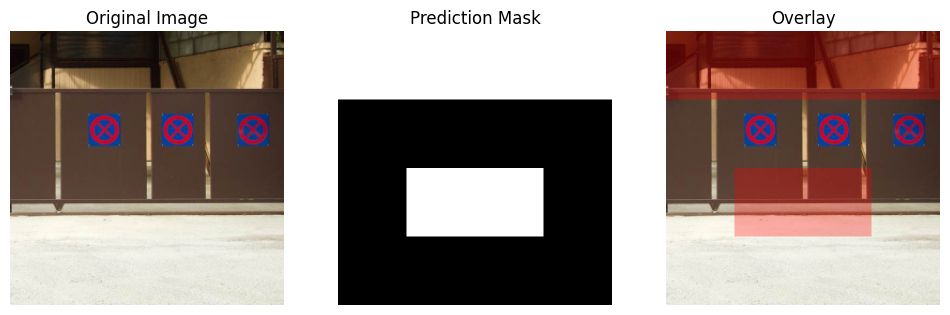

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as T
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

from tensorflow.keras.models import load_model

# ----------------------------
# 1) Load pretrained DINOv3 from Drive
# ----------------------------
dinov3_path = "/content/drive/MyDrive/dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth"

# Load DINOv3 model architecture without downloading weights
dino_model = torch.hub.load("facebookresearch/dinov3", "dinov3_vitb16", pretrained=False)
checkpoint = torch.load(dinov3_path, map_location="cpu")
dino_model.load_state_dict(checkpoint, strict=False)
dino_model.eval()
print("✅ DINOv3 loaded from Google Drive")

# Transformation for patches
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((64, 64)),  # make sure matches your patch size
    T.ToTensor(),
])

# ----------------------------
# 2) Load trained CNN classifier
# ----------------------------
cnn_model = load_model("/content/drive/MyDrive/CMFD_processed/cnn_classifier_best.keras")
print("✅ CNN classifier loaded")

# ----------------------------
# 3) Helper: Split image into patches
# ----------------------------
def extract_patches(img, patch_size=64):
    patches = []
    positions = []
    h, w, _ = img.shape
    for y in range(0, h, patch_size):
        for x in range(0, w, patch_size):
            patch = img[y:y+patch_size, x:x+patch_size]
            if patch.shape[0] == patch_size and patch.shape[1] == patch_size:
                patches.append(patch)
                positions.append((y, x))
    return np.array(patches), positions, (h, w)

# ----------------------------
# 4) Predict mask
# ----------------------------
def predict_mask(img_path, mask_path=None, patch_size=64):
    # Load image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Extract patches
    patches, positions, (H, W) = extract_patches(img, patch_size=patch_size)

    # Extract DINO features
    feats = []
    for p in patches:
        p_t = transform(p).unsqueeze(0)
        with torch.no_grad():
            f = dino_model(p_t).detach().cpu().numpy().flatten()
        feats.append(f)
    feats = np.array(feats)

    # CNN expects (N, 768)
    pred_probs = cnn_model.predict(feats, verbose=0)
    pred_classes = (pred_probs > 0.5).astype(int).flatten()

    # Rebuild mask
    mask_pred = np.zeros((H, W), dtype=np.uint8)
    for (y, x), c in zip(positions, pred_classes):
        if c == 1:
            mask_pred[y:y+patch_size, x:x+patch_size] = 255

    # Load GT mask if available
    mask_gt = None
    if mask_path and os.path.exists(mask_path):
        mask_gt = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask_gt = cv2.resize(mask_gt, (W, H))

    return img, mask_pred, mask_gt

# ----------------------------
# 5) Visualize result
# ----------------------------
img_path = "/content/drive/MyDrive/CMFD_processed/images/009_F_JC6.png"
mask_path = None  # if you have GT, put path here

img, mask_pred, mask_gt = predict_mask(img_path, mask_path)

# Overlay
overlay = img.copy()
overlay[mask_pred == 255] = [255, 0, 0]  # red overlay
overlay = cv2.addWeighted(img, 0.7, overlay, 0.3, 0)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask_pred, cmap="gray")
plt.title("Prediction Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.show()


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov3_main


✅ DINOv3 loaded from Google Drive
✅ CNN classifier loaded


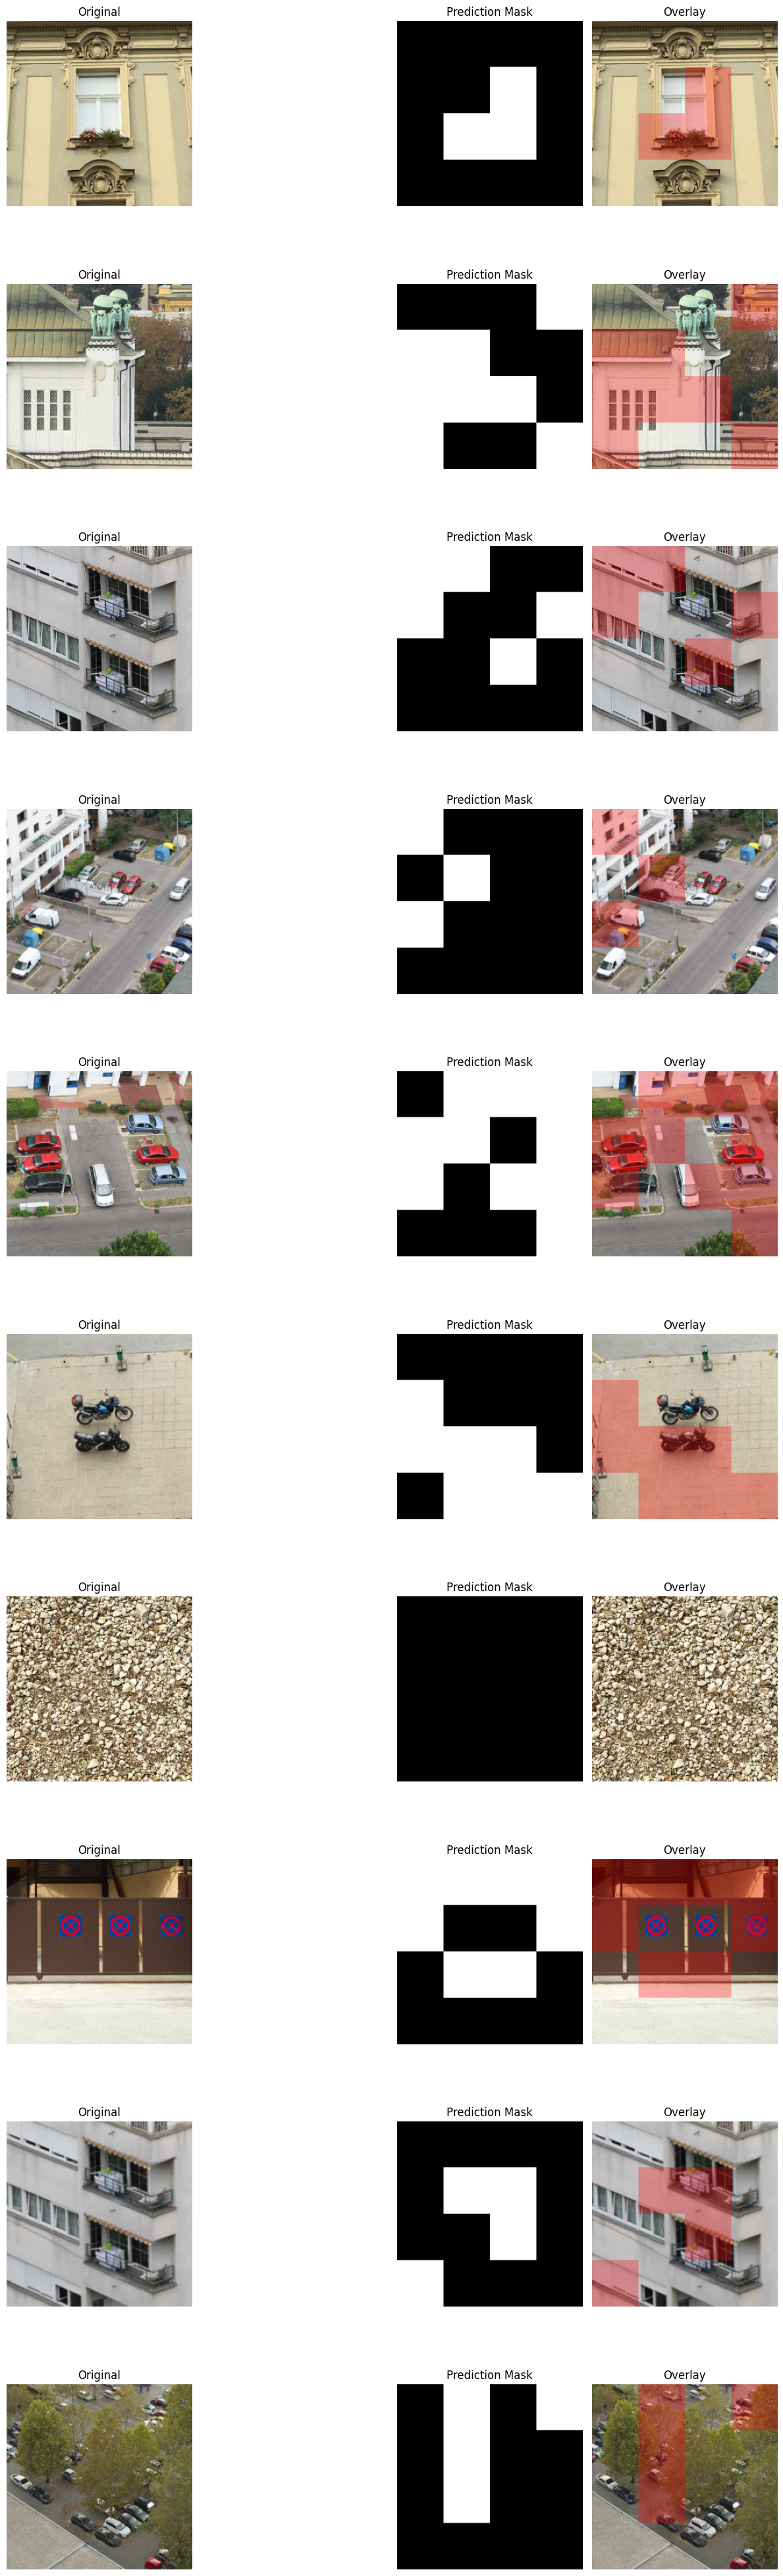

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as T
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
from tensorflow.keras.models import load_model

# ----------------------------
# 1) Load pretrained DINOv3 from Drive
# ----------------------------
dinov3_path = "/content/drive/MyDrive/dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth"

# Load DINOv3 (no internet needed, just arch + checkpoint)
dino_model = torch.hub.load("facebookresearch/dinov3", "dinov3_vitb16", pretrained=False)
checkpoint = torch.load(dinov3_path, map_location="cpu")
dino_model.load_state_dict(checkpoint, strict=False)
dino_model.eval()
print("✅ DINOv3 loaded from Google Drive")

# Transformation for patches
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((64, 64)),  # must match your patch size
    T.ToTensor(),
])

# ----------------------------
# 2) Load trained CNN classifier
# ----------------------------
cnn_model = load_model("/content/drive/MyDrive/CMFD_processed/cnn_classifier_best.keras")
print("✅ CNN classifier loaded")

# ----------------------------
# 3) Patch extraction
# ----------------------------
def extract_patches(img, patch_size=64):
    patches, positions = [], []
    h, w, _ = img.shape
    for y in range(0, h, patch_size):
        for x in range(0, w, patch_size):
            patch = img[y:y+patch_size, x:x+patch_size]
            if patch.shape[0] == patch_size and patch.shape[1] == patch_size:
                patches.append(patch)
                positions.append((y, x))
    return np.array(patches), positions, (h, w)

# ----------------------------
# 4) Predict mask
# ----------------------------
def predict_mask(img_path, mask_path=None, patch_size=64):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    patches, positions, (H, W) = extract_patches(img, patch_size)

    # Extract DINO features
    feats = []
    for p in patches:
        p_t = transform(p).unsqueeze(0)
        with torch.no_grad():
            f = dino_model(p_t).detach().cpu().numpy().flatten()
        feats.append(f)
    feats = np.array(feats)

    # CNN expects (N, 768)
    pred_probs = cnn_model.predict(feats, verbose=0)
    pred_classes = (pred_probs > 0.5).astype(int).flatten()

    mask_pred = np.zeros((H, W), dtype=np.uint8)
    for (y, x), c in zip(positions, pred_classes):
        if c == 1:
            mask_pred[y:y+patch_size, x:x+patch_size] = 255

    mask_gt = None
    if mask_path and os.path.exists(mask_path):
        mask_gt = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask_gt = cv2.resize(mask_gt, (W, H))

    return img, mask_pred, mask_gt

# ----------------------------
# 5) Run on 10 random images
# ----------------------------
IMG_DIR = "/content/drive/MyDrive/CMFD_processed/images"
MASK_DIR = "/content/drive/MyDrive/CMFD_processed/masks"  # optional, if you have GT masks

all_imgs = [f for f in os.listdir(IMG_DIR) if f.endswith((".png",".jpg"))]
sample_imgs = np.random.choice(all_imgs, 10, replace=False)

plt.figure(figsize=(12, 40))
for i, fname in enumerate(sample_imgs, 1):
    img_path = os.path.join(IMG_DIR, fname)
    mask_path = os.path.join(MASK_DIR, fname) if os.path.exists(os.path.join(MASK_DIR, fname)) else None

    img, mask_pred, mask_gt = predict_mask(img_path, mask_path)

    overlay = img.copy()
    overlay[mask_pred == 255] = [255, 0, 0]
    overlay = cv2.addWeighted(img, 0.7, overlay, 0.3, 0)

    # Plot Original | Pred Mask | Overlay (and GT if available)
    plt.subplot(10, 4, 4*(i-1)+1)
    plt.imshow(img); plt.title("Original"); plt.axis("off")

    if mask_gt is not None:
        plt.subplot(10, 4, 4*(i-1)+2)
        plt.imshow(mask_gt, cmap="gray"); plt.title("GT Mask"); plt.axis("off")

    plt.subplot(10, 4, 4*(i-1)+3)
    plt.imshow(mask_pred, cmap="gray"); plt.title("Prediction Mask"); plt.axis("off")

    plt.subplot(10, 4, 4*(i-1)+4)
    plt.imshow(overlay); plt.title("Overlay"); plt.axis("off")

plt.tight_layout()
plt.show()
